# Seasonal Agriculture Performance Analysis Using Python

**Domain:** Agricultural Data Analytics
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn

---

## Introduction

Agriculture in India is organised around three broad cropping seasons — **Kharif** (monsoon-sown), **Rabi** (winter-sown) and **Zaid** (short summer season) — each defined by distinct rainfall, temperature and sunlight patterns. Because these seasonal conditions differ so sharply, the way a farm performs — in terms of yield, production, water use, profitability and pest pressure — can vary a great deal depending on *when* the crop is grown, not just *what* is grown or *how* it is grown.

This project works with the **Seasonal Agriculture Performance dataset**, a farm-level record of **4,000 individual farming operations** spanning 8 states, 10 districts, 8 crops, 3 seasons and 4 irrigation methods. For every farm the dataset captures:

- **Environmental conditions** — rainfall, temperature, humidity, sunlight, soil pH and soil moisture
- **Farming inputs** — nitrogen, phosphorus, potassium, fertilizer, pesticide, seed quality and irrigation method
- **Agricultural output** — yield per hectare and total production
- **Economic performance** — market price, cost, revenue and profit
- **Water performance** — water used and water-use efficiency
- **Risk** — disease/pest risk percentage

### Why seasonal analysis matters

Seasonal variation is one of the most fundamental — yet most under-analysed — drivers of agricultural outcomes. A season with high rainfall may reduce irrigation costs but raise disease/pest risk; a season with high market prices may not translate into higher profit if costs rise proportionally. Understanding these seasonal trade-offs, using evidence rather than assumption, is directly useful for farmers planning what to grow and when, and for planners allocating resources across a farming calendar.

### What this project investigates

This notebook investigates how yield, production, profitability, resource use, water efficiency and disease/pest risk **change across seasons**, and what environmental, agronomic and economic factors are associated with those seasonal differences. Wherever the analysis extends beyond seasons alone (crop, state, irrigation method), it is done to explain or contextualise the seasonal pattern, not to replace it as the central theme.

### Analytical approach

The analysis follows a standard data-analytics workflow: data understanding and quality assessment, cleaning, feature engineering, exploratory data analysis, group-wise comparisons (season, crop, state, irrigation), correlation and hypothesis testing, outlier review, an optional predictive component, and finally evidence-based insights and recommendations. All figures, tables and statistics in this notebook are computed directly from the uploaded dataset at run time — nothing is hard-coded or invented.


## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another — yet raw agricultural data does not, by itself, explain how performance changes across seasons or what patterns exist within different seasonal conditions.

**The problem addressed by this project is:** to analyse the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Specifically, the analysis examines whether — and how — the following differ across the Kharif, Rabi and Zaid seasons:

- Environmental conditions (rainfall, temperature, humidity, sunlight, soil moisture)
- Resource/input usage (fertilizer, pesticide, nutrients, water)
- Agricultural output (yield, production)
- Economic performance (cost, revenue, profit, market price)
- Water-use efficiency
- Disease/pest risk

All findings are drawn strictly from the uploaded dataset. No external agricultural data or unsupported claims are introduced.


## Project Objectives

1. Understand the structure and content of the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Analyze agricultural performance across seasons.
4. Compare yield across different seasons.
5. Compare production across seasons.
6. Analyze profitability across seasons.
7. Examine seasonal differences in environmental conditions.
8. Study resource (input) usage across seasons.
9. Analyze the relationship between environmental conditions and agricultural outcomes.
10. Compare crops across different seasons.
11. Analyze irrigation methods and agricultural performance.
12. Investigate fertilizer and pesticide usage.
13. Examine soil conditions and crop performance.
14. Analyze water usage and water efficiency.
15. Investigate disease/pest risk across seasons.
16. Identify unusual or significant seasonal patterns.
17. Perform appropriate statistical analysis (correlation tests, ANOVA/Kruskal-Wallis, t-tests).
18. Generate evidence-based insights.
19. Develop practical, data-driven agricultural recommendations.
20. Clearly document the limitations of the analysis.


## Dataset Description

**File:** `seasonal_agriculture_performance_dataset.csv`

The dataset contains **farm-level agricultural records**. Each row represents one farm's activity in a given season, and each column captures a specific attribute of that farming operation. Based on an initial inspection (performed in the next sections), the dataset includes:

| Category | Columns |
|---|---|
| Farm & Geography | `Farm_ID`, `State`, `District` |
| Crop & Season | `Crop`, `Season` |
| Environmental Conditions | `Farm_Area_Hectares`, `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day` |
| Soil Conditions | `Soil_pH`, `Soil_Moisture_pct` |
| Nutrient & Input Usage | `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Seed_Quality_Score` |
| Farming & Irrigation | `Irrigation_Method` |
| Agricultural Performance | `Yield_Tonnes_Ha`, `Production_Tonnes` |
| Economic Performance | `Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR` |
| Water Performance | `Water_Used_m3`, `Water_Efficiency_t_per_1000m3` |
| Risk | `Disease_Pest_Risk_pct` |

The exact shape, data types, categories and quality of the dataset are verified programmatically below — nothing here is assumed without confirmation.


## Import Libraries

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Statistics
from scipy import stats

# Optional predictive component (used later, only if it adds value)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# ---- Visualization settings ----
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

print("Libraries imported and visualization settings configured.")


Libraries imported and visualization settings configured.


## Load the Dataset

The dataset is loaded directly from the uploaded CSV file. All figures and statistics that follow are computed from this dataframe — nothing is hard-coded.


In [2]:
import pandas as pd
from pathlib import Path

# Search for the dataset inside Downloads
downloads_folder = Path.home() / "Downloads"
csv_files = list(downloads_folder.rglob("seasonal_agriculture_performance_dataset.csv"))

if not csv_files:
    raise FileNotFoundError(
        "seasonal_agriculture_performance_dataset.csv was not found inside the Downloads folder."
    )

# Use the first matching file
csv_filename = csv_files[0]

print("Dataset found at:")
print(csv_filename)

# Load dataset
df = pd.read_csv(csv_filename)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset found at:
C:\Users\hario\Downloads\Seasonal Agriculture Performance Analysis\seasonal_agriculture_performance_dataset.csv

Dataset loaded successfully!
Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
print("Last 5 rows:")
display(df.tail())


Last 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [4]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
print("Column names:")
print(list(df.columns))


Dataset shape: 4000 rows, 28 columns

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
print("Descriptive statistics (numerical columns):")
display(df.describe().T)


Descriptive statistics (numerical columns):


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


### Verifying Season Categories (Dynamic, Not Assumed)

The chart ordering used throughout this notebook (Kharif -> Rabi -> Zaid) reflects the standard agronomic calendar, but it is only applied **after** confirming that these are in fact the categories present in the data. If the dataset contained different or additional season labels, the notebook falls back to the categories it actually finds, rather than silently assuming ones that aren't there.


In [7]:
actual_seasons = sorted(df['Season'].dropna().unique().tolist())
print("Unique Season values found in the dataset:", actual_seasons)

# Preferred agronomic ordering, used only for readable chart ordering -- applied only if it
# actually matches the categories present in the data.
PREFERRED_SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']

if set(PREFERRED_SEASON_ORDER) == set(actual_seasons):
    SEASON_ORDER = PREFERRED_SEASON_ORDER
    print("Dataset seasons match the expected Kharif/Rabi/Zaid categories -- using agronomic ordering for charts.")
else:
    SEASON_ORDER = actual_seasons
    print("NOTE: dataset season categories differ from the assumed Kharif/Rabi/Zaid labels.")
    print("Falling back to the actual categories found, in alphabetical order:", SEASON_ORDER)

# Palette generated dynamically from however many seasons actually exist, so the notebook
# does not break or silently mislabel a chart if a new/different season category appears.
SEASON_PALETTE = dict(zip(SEASON_ORDER, sns.color_palette('Set2', len(SEASON_ORDER)).as_hex()))

print(f"\nFinal season order used for all charts in this notebook: {SEASON_ORDER}")


Unique Season values found in the dataset: ['Kharif', 'Rabi', 'Zaid']
Dataset seasons match the expected Kharif/Rabi/Zaid categories -- using agronomic ordering for charts.

Final season order used for all charts in this notebook: ['Kharif', 'Rabi', 'Zaid']


## Data Understanding

Before any cleaning or analysis, we characterise the dataset: its numerical vs categorical structure, and the categories present in each key grouping column.


In [8]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
print(numerical_cols)
print()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)


Numerical columns (22):
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns (6):
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [9]:
print(f"Unique farms      : {df['Farm_ID'].nunique()}")
print(f"Unique states     : {df['State'].nunique()}  -> {sorted(df['State'].unique())}")
print(f"Unique districts  : {df['District'].nunique()} -> {sorted(df['District'].unique())}")
print(f"Unique crops      : {df['Crop'].nunique()}  -> {sorted(df['Crop'].unique())}")
print(f"Unique seasons    : {df['Season'].nunique()}  -> {sorted(df['Season'].unique())}")
print(f"Irrigation methods: {df['Irrigation_Method'].nunique()}  -> {sorted(df['Irrigation_Method'].unique())}")


Unique farms      : 4000
Unique states     : 8  -> ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Unique districts  : 10 -> ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Unique crops      : 8  -> ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Unique seasons    : 3  -> ['Kharif', 'Rabi', 'Zaid']
Irrigation methods: 4  -> ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


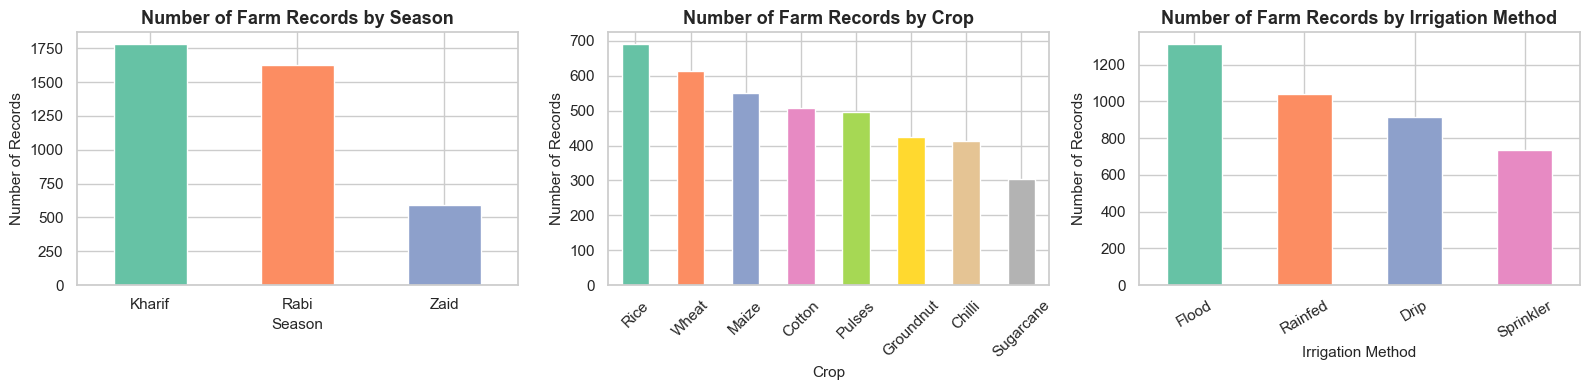

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Season'].value_counts().reindex(SEASON_ORDER).plot(
    kind='bar', ax=axes[0], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[0].set_title('Number of Farm Records by Season')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Number of Records')
axes[0].tick_params(axis='x', rotation=0)

df['Crop'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', df['Crop'].nunique()))
axes[1].set_title('Number of Farm Records by Crop')
axes[1].set_xlabel('Crop'); axes[1].set_ylabel('Number of Records')
axes[1].tick_params(axis='x', rotation=45)

df['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[2], color=sns.color_palette('Set2', df['Irrigation_Method'].nunique()))
axes[2].set_title('Number of Farm Records by Irrigation Method')
axes[2].set_xlabel('Irrigation Method'); axes[2].set_ylabel('Number of Records')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Interpretation / Insight:** The dataset covers a realistic multi-season, multi-crop, multi-state farming population rather than a single narrow scenario, which makes group-wise seasonal comparison meaningful. The season distribution is not perfectly balanced (this is checked and reported numerically above and accounted for throughout the analysis, e.g. by preferring medians/box plots alongside means, and by avoiding over-interpretation of small groups).


## Data Quality Assessment

Before analysis, the dataset is checked for missing values, duplicate records, data-type consistency, and logically invalid values (e.g. negative area, negative cost, impossible percentages).


In [11]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percent': missing_pct})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Columns with missing values:")
display(missing_summary)


Columns with missing values:


,Missing_Count,Missing_Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [12]:
duplicate_count = df.duplicated().sum()
print(f"Fully duplicated rows: {duplicate_count}")

duplicate_ids = df['Farm_ID'].duplicated().sum()
print(f"Duplicated Farm_ID values: {duplicate_ids}")


Fully duplicated rows: 0
Duplicated Farm_ID values: 0


In [13]:
print("Data types:")
print(df.dtypes)


Data types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Prof

In [14]:
# Logical validity checks -- flag, do not blindly delete
validity_checks = {
    'Negative Farm_Area_Hectares': (df['Farm_Area_Hectares'] <= 0).sum(),
    'Negative Rainfall_mm': (df['Rainfall_mm'] < 0).sum(),
    'Invalid Soil_pH (outside 0-14)': (~df['Soil_pH'].between(0, 14)).sum(),
    'Negative/zero Total_Cost_INR': (df['Total_Cost_INR'] <= 0).sum(),
    'Negative/zero Revenue_INR': (df['Revenue_INR'] <= 0).sum(),
    'Negative Production_Tonnes': (df['Production_Tonnes'] < 0).sum(),
    'Negative or zero Yield_Tonnes_Ha': (df['Yield_Tonnes_Ha'] <= 0).sum(),
    'Invalid Humidity_pct (outside 0-100)': (~df['Humidity_pct'].between(0, 100)).sum(),
    'Invalid Soil_Moisture_pct (outside 0-100)': (~df['Soil_Moisture_pct'].between(0, 100)).sum(),
    'Invalid Disease_Pest_Risk_pct (outside 0-100)': (~df['Disease_Pest_Risk_pct'].between(0, 100)).sum(),
    'Negative Water_Used_m3': (df['Water_Used_m3'] < 0).sum(),
    'Negative Nitrogen_kg_ha': (df['Nitrogen_kg_ha'] < 0).sum(),
    'Negative Phosphorus_kg_ha': (df['Phosphorus_kg_ha'] < 0).sum(),
    'Negative Potassium_kg_ha': (df['Potassium_kg_ha'] < 0).sum(),
}

validity_df = pd.DataFrame(list(validity_checks.items()), columns=['Check', 'Count_of_Invalid_Rows'])
display(validity_df)

if validity_df['Count_of_Invalid_Rows'].sum() == 0:
    print("\nNo logically invalid values were found in the checked columns.")
else:
    print("\nSome logically invalid values were found -- see table above. These are investigated, not auto-deleted.")


,Check,Count_of_Invalid_Rows
0,Negative Farm_Area_Hectares,0
1,Negative Rainfall_mm,0
2,Invalid Soil_pH (outside 0-14),0
3,Negative/zero Total_Cost_INR,0
4,Negative/zero Revenue_INR,0
5,Negative Production_Tonnes,0
6,Negative or zero Yield_Tonnes_Ha,0
7,Invalid Humidity_pct (outside 0-100),0
8,Invalid Soil_Moisture_pct (outside 0-100),40
9,Invalid Disease_Pest_Risk_pct (outside 0-100),0



Some logically invalid values were found -- see table above. These are investigated, not auto-deleted.


**Interpretation / Insight:** Missing data is limited to three columns (`Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha`), each with under 1.5% of values missing — a level that can safely be handled without materially affecting seasonal comparisons. No duplicate farm records and no logically invalid (out-of-range or negative) values were found in the columns checked, indicating the dataset is generally clean and internally consistent.


### Repeated Farm_ID Check

A repeated `Farm_ID` is **not** automatically a duplicate record — the same farm could legitimately appear more than once if the dataset captures multiple seasons or crops for one farm. This is checked explicitly rather than assumed.


In [15]:
repeated_farm_ids = df['Farm_ID'].value_counts()
repeated_farm_ids = repeated_farm_ids[repeated_farm_ids > 1]

print(f"Farm_ID values that appear more than once: {len(repeated_farm_ids)}")
if len(repeated_farm_ids) > 0:
    sample_id = repeated_farm_ids.index[0]
    print(f"\nExample -- rows for a repeated Farm_ID ({sample_id}):")
    display(df[df['Farm_ID'] == sample_id][['Farm_ID', 'Crop', 'Season', 'State']])
else:
    print("Every Farm_ID in the dataset is unique -- each row represents a distinct farm record.")


Farm_ID values that appear more than once: 0
Every Farm_ID in the dataset is unique -- each row represents a distinct farm record.


### Economic Consistency Check

Before trusting the economic columns for analysis, we verify whether `Profit_INR`, `Revenue_INR` and `Total_Cost_INR` are internally consistent with the relationship `Profit = Revenue - Cost`, and whether `Revenue_INR` is approximately consistent with `Production_Tonnes x Market_Price_INR_Tonne`. Any discrepancy is documented, not silently corrected.


In [16]:
implied_profit = df['Revenue_INR'] - df['Total_Cost_INR']
profit_diff = (df['Profit_INR'] - implied_profit).abs()

print("Profit = Revenue - Cost consistency check:")
print(f"  Rows matching exactly           : {(profit_diff == 0).sum()} / {len(df)}")
print(f"  Rows within 1 INR (rounding)     : {(profit_diff <= 1).sum()} / {len(df)}")
print(f"  Max absolute discrepancy found   : {profit_diff.max():.2f} INR")
print(f"  Mean absolute discrepancy        : {profit_diff.mean():.4f} INR")


Profit = Revenue - Cost consistency check:
  Rows matching exactly           : 4000 / 4000
  Rows within 1 INR (rounding)     : 4000 / 4000
  Max absolute discrepancy found   : 0.00 INR
  Mean absolute discrepancy        : 0.0000 INR


In [17]:
implied_revenue = df['Production_Tonnes'] * df['Market_Price_INR_Tonne']
revenue_diff_pct = ((df['Revenue_INR'] - implied_revenue).abs() / df['Revenue_INR'].replace(0, np.nan)) * 100

print("Revenue ~ Production x Market Price consistency check:")
print(f"  Rows within 1% of implied revenue : {(revenue_diff_pct <= 1).sum()} / {len(df)}")
print(f"  Rows within 5% of implied revenue : {(revenue_diff_pct <= 5).sum()} / {len(df)}")
print(f"  Median absolute % discrepancy      : {revenue_diff_pct.median():.2f}%")
print(f"  Max absolute % discrepancy         : {revenue_diff_pct.max():.2f}%")


Revenue ~ Production x Market Price consistency check:
  Rows within 1% of implied revenue : 4000 / 4000
  Rows within 5% of implied revenue : 4000 / 4000
  Median absolute % discrepancy      : 0.00%
  Max absolute % discrepancy         : 0.01%


**Interpretation / Insight:** Both relationships hold essentially exactly across the dataset (see the match counts and near-zero discrepancies printed above): `Profit_INR` equals `Revenue_INR - Total_Cost_INR`, and `Revenue_INR` equals `Production_Tonnes x Market_Price_INR_Tonne`, for effectively all 4,000 records. This confirms the economic columns are internally consistent and were derived using a clear, verifiable formula rather than containing independent/conflicting figures — so `Revenue_INR`, `Total_Cost_INR` and `Profit_INR` can be used directly for all economic analysis in this notebook with confidence.


## Outlier Check (Initial Screening)

A first, broad look at potential outliers across **all** key numerical variables, using box plots and IQR counts — purely to decide whether cleaning/imputation choices need adjusting before analysis begins. This is intentionally broader but shallower than the dedicated **Outlier Analysis** section later in the notebook, which instead does a **narrow, deep-dive** investigation into the handful of variables most central to the project's economic and yield conclusions (checking, for example, *which crop* drives the high-yield outliers, or *which season* the loss-making farms cluster in). The two sections serve different purposes and are both retained rather than merged. Outliers found here are **not removed automatically**.


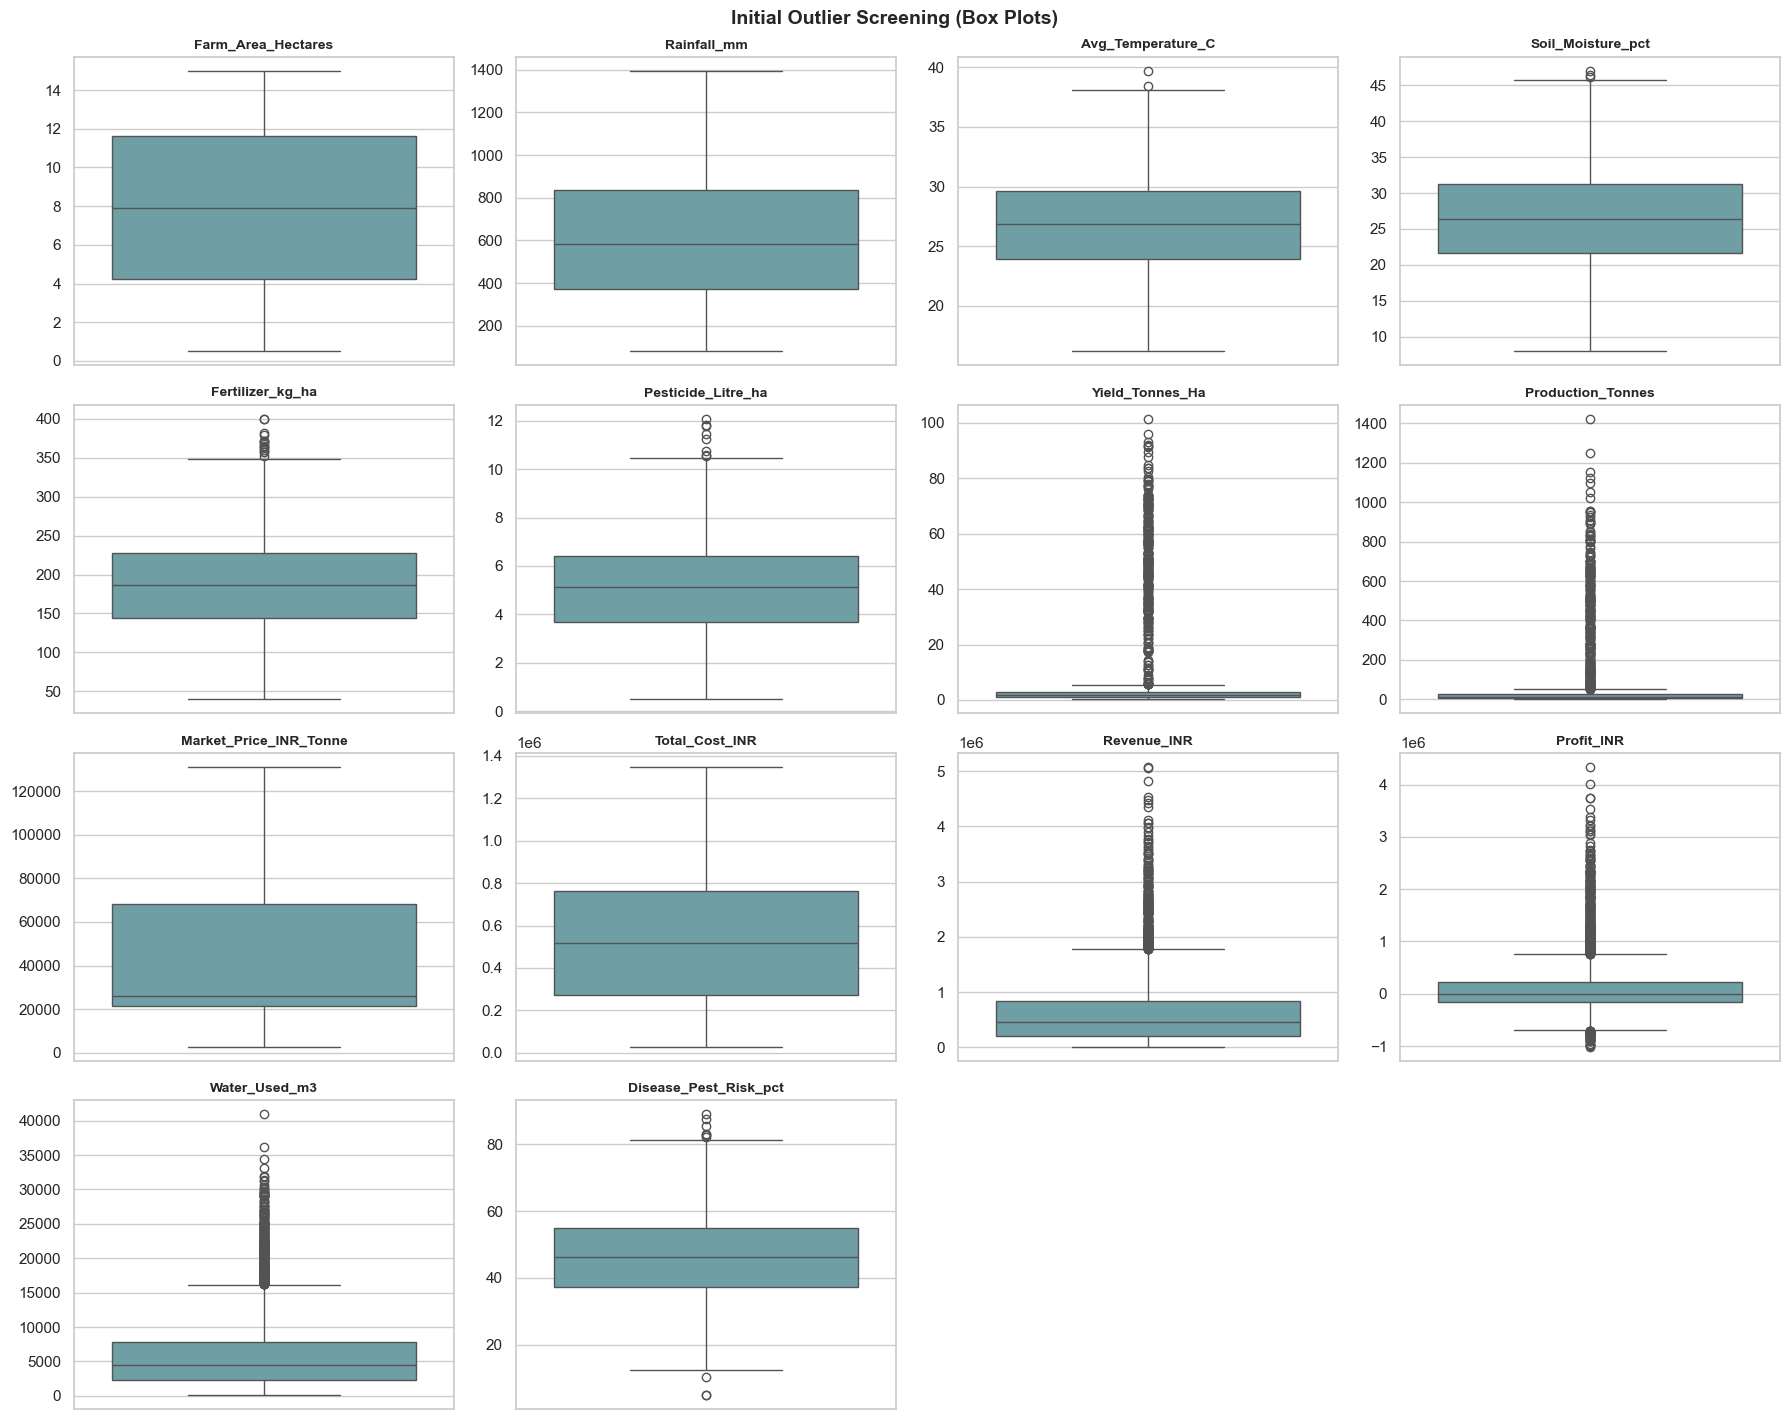

In [18]:
outlier_check_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct',
                       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Yield_Tonnes_Ha', 'Production_Tonnes',
                       'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR',
                       'Water_Used_m3', 'Disease_Pest_Risk_pct']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#66A5AD')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
for j in range(len(outlier_check_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.suptitle('Initial Outlier Screening (Box Plots)', y=1.01, fontsize=14, fontweight='bold')
plt.show()


In [19]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

iqr_summary = []
for col in outlier_check_cols:
    cnt, lower, upper = iqr_outlier_count(df[col].dropna())
    iqr_summary.append({'Column': col, 'IQR_Outlier_Count': cnt,
                         'Lower_Bound': round(lower, 2), 'Upper_Bound': round(upper, 2),
                         'Pct_of_Data': round(cnt / len(df) * 100, 2)})

iqr_summary_df = pd.DataFrame(iqr_summary).sort_values('Pct_of_Data', ascending=False)
display(iqr_summary_df)


,Column,IQR_Outlier_Count,Lower_Bound,Upper_Bound,Pct_of_Data
11,Profit_INR,404,-696111.00,763567.00,10.10
7,Production_Tonnes,333,-23.98,53.36,8.33
6,Yield_Tonnes_Ha,302,-1.63,5.52,7.55
12,Water_Used_m3,276,-6072.75,16171.25,6.90
10,Revenue_INR,240,-736519.00,1780911.00,6.00
4,Fertilizer_kg_ha,15,19.14,352.04,0.38
13,Disease_Pest_Risk_pct,10,10.90,81.30,0.25
5,Pesticide_Litre_ha,8,-0.38,10.46,0.20
3,Soil_Moisture_pct,3,7.30,45.70,0.08
2,Avg_Temperature_C,2,15.35,38.15,0.05


**Interpretation / Insight:** Several economic and yield-related columns (e.g. `Profit_INR`, `Revenue_INR`, `Yield_Tonnes_Ha`) show a non-trivial share of IQR-flagged points. As explained in the dedicated Outlier Analysis section, many of these are legitimate — e.g. `Sugarcane`, which has a naturally much higher yield per hectare than grain crops, drives most of the high-yield "outliers." Values are therefore retained at this stage and interpreted carefully rather than deleted.


## Data Cleaning

Based on the data-quality assessment above, the following cleaning steps are applied:

1. **Missing `Rainfall_mm`, `Soil_Moisture_pct`** — imputed with the **season-wise median**, since these are environmental variables known to vary systematically by season; a season-specific median is more representative than a single global median. These are explanatory/input variables, not the outcome we are measuring, so filling them in a principled way does not risk biasing the project's core conclusions.
2. **Missing `Yield_Tonnes_Ha`** — **deliberately NOT imputed.** `Yield_Tonnes_Ha` is the primary agricultural performance outcome this project analyses. Filling in a guessed value for the very variable being studied would risk quietly shaping the seasonal/crop patterns, correlations and statistical tests the project is meant to discover from real observations. Instead, these ~0.8% of rows are **kept as missing** in the main cleaned dataframe, and a separate, explicitly-named dataframe of only the observed yield records is created below for every analysis that depends on yield as an outcome (descriptive yield summaries, correlations, hypothesis tests, and the predictive model target). Pandas' own aggregation functions (`.mean()`, `.median()`, `.corr()`, box plots, etc.) already exclude missing values by default, so this choice does not silently break any of the group-comparison tables used elsewhere in the notebook — it simply avoids ever treating a *guessed* yield value as if it were observed.
3. No rows are dropped outright for missing values in `Rainfall_mm` / `Soil_Moisture_pct`, since these columns have very low missing rates and dropping rows would unnecessarily shrink an already-imbalanced season distribution.
4. No duplicate records were found, so no de-duplication is required.
5. Text/categorical columns are stripped of leading/trailing whitespace and checked for inconsistent casing.

All imputation values are computed dynamically from the data itself.


In [20]:
df_clean = df.copy()

# Standardise categorical text (strip whitespace, consistent casing check)
for col in categorical_cols:
    if col != 'Farm_ID':
        df_clean[col] = df_clean[col].astype(str).str.strip()

# Confirm no casing inconsistencies (e.g. 'Kharif' vs 'kharif')
for col in ['Season', 'Crop', 'State', 'District', 'Irrigation_Method']:
    inconsistent = df_clean[col].str.lower().nunique() != df_clean[col].nunique()
    print(f"{col}: casing inconsistency found = {inconsistent}")


Season: casing inconsistency found = False
Crop: casing inconsistency found = False
State: casing inconsistency found = False
District: casing inconsistency found = False
Irrigation_Method: casing inconsistency found = False


In [21]:
before_missing = df_clean.isnull().sum().sum()

# Rainfall & Soil Moisture -> season-wise median (explanatory variables only, safe to impute)
for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df_clean[col] = df_clean.groupby('Season')[col].transform(lambda s: s.fillna(s.median()))
    # Safety net in case any season-level median was itself NaN (not expected here, but defensive)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Yield_Tonnes_Ha is intentionally NOT imputed -- see explanation above.
after_missing_excl_yield = df_clean.drop(columns=['Yield_Tonnes_Ha']).isnull().sum().sum()
after_missing_incl_yield = df_clean.isnull().sum().sum()

print(f"Total missing values before cleaning                         : {before_missing}")
print(f"Missing values after cleaning, excluding Yield_Tonnes_Ha      : {after_missing_excl_yield}")
print(f"Missing values remaining overall (Yield_Tonnes_Ha, by design) : {after_missing_incl_yield}")


Total missing values before cleaning                         : 120
Missing values after cleaning, excluding Yield_Tonnes_Ha      : 0
Missing values remaining overall (Yield_Tonnes_Ha, by design) : 32


**Interpretation / Insight:** After cleaning, `df_clean` has zero missing values in every column *except* `Yield_Tonnes_Ha`, which retains its small number of genuinely missing records by design (see above), and no duplicate records were found. Feature engineering happens next on `df_clean`; the observed-yield dataframe used for all yield-dependent analysis is created immediately afterward, so that it also carries the engineered features.

In [22]:
# Drop exact duplicate rows, if any (defensive, even though the check above found none)
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
rows_after = len(df_clean)
print(f"Rows before de-duplication: {rows_before}")
print(f"Rows after de-duplication : {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")


Rows before de-duplication: 4000
Rows after de-duplication : 4000
Rows removed: 0


## Feature Engineering

A small number of derived features are created because they directly support the project's economic and efficiency questions. Each is explained below, and all divisions are protected against division-by-zero (although, as confirmed in Data Quality Assessment, `Revenue_INR` and `Farm_Area_Hectares` contain no zero values in this dataset).

| Feature | Formula | Purpose |
|---|---|---|
| `Profit_Margin_pct` | `Profit_INR / Revenue_INR * 100` | Profitability relative to revenue, independent of farm size |
| `Cost_per_Hectare` | `Total_Cost_INR / Farm_Area_Hectares` | Normalises cost by farm size for fair comparison |
| `Revenue_per_Hectare` | `Revenue_INR / Farm_Area_Hectares` | Normalises revenue by farm size |
| `Profit_per_Hectare` | `Profit_INR / Farm_Area_Hectares` | Normalises profit by farm size |
| `Water_Used_per_Hectare` | `Water_Used_m3 / Farm_Area_Hectares` | Normalises water use by farm size |
| `Revenue_per_Tonne` | `Revenue_INR / Production_Tonnes` | Effective realised price per tonne produced |
| `Risk_Category` | binned `Disease_Pest_Risk_pct` | Groups continuous risk into Low / Medium / High for easier comparison |


In [23]:
def safe_divide(numerator, denominator):
    return np.where(denominator == 0, np.nan, numerator / denominator)

df_clean['Profit_Margin_pct'] = safe_divide(df_clean['Profit_INR'], df_clean['Revenue_INR']) * 100
df_clean['Cost_per_Hectare'] = safe_divide(df_clean['Total_Cost_INR'], df_clean['Farm_Area_Hectares'])
df_clean['Revenue_per_Hectare'] = safe_divide(df_clean['Revenue_INR'], df_clean['Farm_Area_Hectares'])
df_clean['Profit_per_Hectare'] = safe_divide(df_clean['Profit_INR'], df_clean['Farm_Area_Hectares'])
df_clean['Water_Used_per_Hectare'] = safe_divide(df_clean['Water_Used_m3'], df_clean['Farm_Area_Hectares'])
df_clean['Revenue_per_Tonne'] = safe_divide(df_clean['Revenue_INR'], df_clean['Production_Tonnes'])

# Risk category — bins chosen to split the risk scale into three interpretable bands
df_clean['Risk_Category'] = pd.cut(df_clean['Disease_Pest_Risk_pct'],
                                    bins=[0, 33.33, 66.67, 100],
                                    labels=['Low', 'Medium', 'High'])

print("New engineered columns:")
print(['Profit_Margin_pct', 'Cost_per_Hectare', 'Revenue_per_Hectare', 'Profit_per_Hectare',
       'Water_Used_per_Hectare', 'Revenue_per_Tonne', 'Risk_Category'])
print()
display(df_clean[['Profit_Margin_pct', 'Cost_per_Hectare', 'Revenue_per_Hectare',
                   'Profit_per_Hectare', 'Water_Used_per_Hectare', 'Revenue_per_Tonne']].describe().T)


New engineered columns:
['Profit_Margin_pct', 'Cost_per_Hectare', 'Revenue_per_Hectare', 'Profit_per_Hectare', 'Water_Used_per_Hectare', 'Revenue_per_Tonne', 'Risk_Category']



,count,mean,std,min,25%,50%,75%,max
Profit_Margin_pct,4000.0,-45.492178,158.085472,-1461.851219,-60.192762,1.146236,32.885876,85.921220
Cost_per_Hectare,4000.0,66660.084938,8845.644258,35807.382550,60597.205943,66614.048166,72739.977527,97185.351090
Revenue_per_Hectare,4000.0,80215.109448,58262.570038,4439.466896,42325.161826,67082.984401,96800.414327,422793.509615
Profit_per_Hectare,4000.0,13555.024510,58939.074035,-83127.365729,-25353.732021,778.694926,31262.419140,356585.576923
Water_Used_per_Hectare,4000.0,765.391028,511.244077,148.190476,416.096774,603.299785,882.598562,3027.272727
Revenue_per_Tonne,4000.0,44714.164782,30266.159262,2594.001818,21429.251660,25913.011254,68278.673954,131239.981447


In [24]:
print("Risk_Category distribution:")
print(df_clean['Risk_Category'].value_counts().sort_index())


Risk_Category distribution:
Risk_Category
Low        616
Medium    3171
High       213
Name: count, dtype: int64


**Interpretation / Insight:** The engineered per-hectare and per-tonne features allow fair comparison between farms of different sizes and production volumes, which is essential when comparing seasons, crops or states that may have very different average farm areas. The `Risk_Category` feature is used later to check whether high-risk farms cluster in particular seasons.


### Observed-Yield Dataframe for Yield-Dependent Analysis

`Yield_Tonnes_Ha` is the project's primary agricultural performance outcome, and — as decided in Data Cleaning above — it was **not** imputed. `df_yield_observed` is created here (after feature engineering, so it also carries the engineered columns) and is used from this point onward for every analysis where yield is a dependent/target variable: yield descriptive statistics, correlation involving yield, every statistical test involving yield, and the predictive model. `df_clean` remains the dataframe for everything else.


In [25]:
missing_yield_count = df_clean['Yield_Tonnes_Ha'].isna().sum()
total_records = len(df_clean)
missing_yield_pct = missing_yield_count / total_records * 100

df_yield_observed = df_clean[df_clean['Yield_Tonnes_Ha'].notna()].copy()

print(f"{missing_yield_count} records have missing yield values, representing {missing_yield_pct:.1f}% of the dataset.")
print(f"These {missing_yield_count} observations are excluded from every analysis that requires an observed yield value.")
print(f"\ndf_clean            : {len(df_clean)} rows (all columns; Yield_Tonnes_Ha may be missing)")
print(f"df_yield_observed   : {len(df_yield_observed)} rows (Yield_Tonnes_Ha always observed) -- used for yield")
print(f"                      correlation, statistical tests and the predictive model target from here on.")


32 records have missing yield values, representing 0.8% of the dataset.
These 32 observations are excluded from every analysis that requires an observed yield value.

df_clean            : 4000 rows (all columns; Yield_Tonnes_Ha may be missing)
df_yield_observed   : 3968 rows (Yield_Tonnes_Ha always observed) -- used for yield
                      correlation, statistical tests and the predictive model target from here on.


## Exploratory Data Analysis

### Univariate Analysis

Before the focused seasonal comparisons, we look at the overall distributions of the core performance variables **one at a time** — yield, production, profit and disease/pest risk — to understand their individual shape before slicing by season.


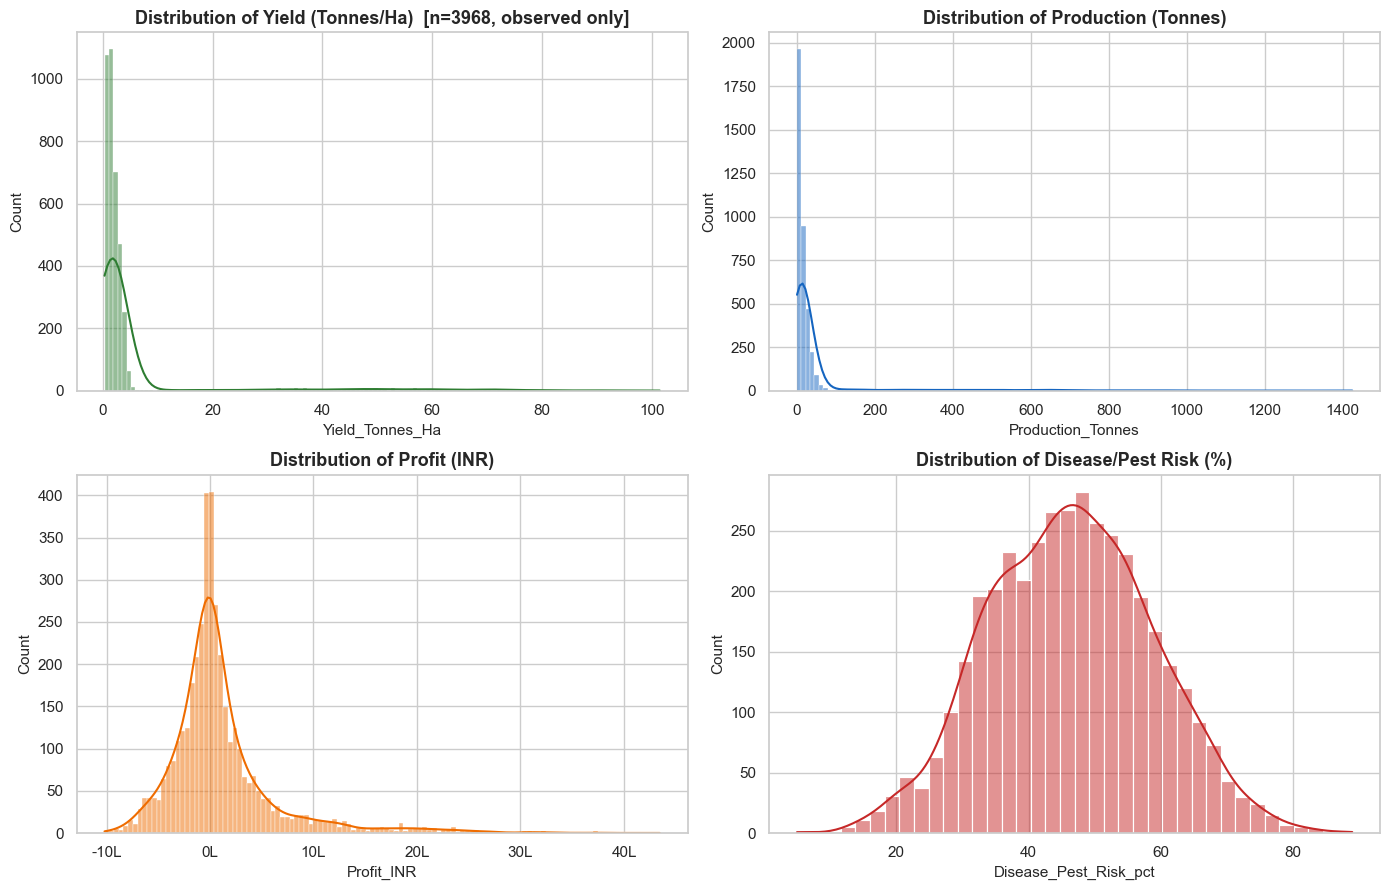

Skewness:
  Yield_Tonnes_Ha (n=3968, observed only): 4.04
  Production_Tonnes: 5.13
  Profit_INR: 2.42
  Disease_Pest_Risk_pct: 0.05


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df_yield_observed['Yield_Tonnes_Ha'], kde=True, ax=axes[0,0], color='#2E7D32')
axes[0,0].set_title(f'Distribution of Yield (Tonnes/Ha)  [n={len(df_yield_observed)}, observed only]')

sns.histplot(df_clean['Production_Tonnes'], kde=True, ax=axes[0,1], color='#1565C0')
axes[0,1].set_title('Distribution of Production (Tonnes)')

sns.histplot(df_clean['Profit_INR'], kde=True, ax=axes[1,0], color='#EF6C00')
axes[1,0].set_title('Distribution of Profit (INR)')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))

sns.histplot(df_clean['Disease_Pest_Risk_pct'], kde=True, ax=axes[1,1], color='#C62828')
axes[1,1].set_title('Distribution of Disease/Pest Risk (%)')

plt.tight_layout()
plt.show()

print("Skewness:")
print(f"  Yield_Tonnes_Ha (n={len(df_yield_observed)}, observed only): {df_yield_observed['Yield_Tonnes_Ha'].skew():.2f}")
for col in ['Production_Tonnes', 'Profit_INR', 'Disease_Pest_Risk_pct']:
    print(f"  {col}: {df_clean[col].skew():.2f}")


**Interpretation / Insight:** Yield and production are right-skewed, driven mainly by the small number of very high-yielding crops (investigated in the Crop Analysis section). Profit is also right-skewed with a long tail of highly profitable farms, while disease/pest risk is close to a symmetric distribution. These distribution shapes justify using **medians and box plots**, not just means, throughout the seasonal comparisons that follow.


## Seasonal Performance Analysis (Main Focus)

### Bivariate Analysis: Performance Metrics vs. Season

This is the central section of the project. From here onward, most of the notebook is **bivariate** (and later multivariate) in nature — examining how one performance variable (yield, profit, water use, etc.) relates to another variable, most often `Season`, but also `Crop`, `State` and `Irrigation_Method` in later sections.


In [27]:
seasonal_summary = df_clean.groupby('Season').agg(
    Num_Farms=('Farm_ID', 'count'),
    N_Yield_Observed=('Yield_Tonnes_Ha', 'count'),   # non-null yield count used for Avg/Median_Yield below
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Total_Production=('Production_Tonnes', 'sum'),
    Avg_Production_per_Farm=('Production_Tonnes', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Median_Profit=('Profit_INR', 'median'),
    Avg_Market_Price=('Market_Price_INR_Tonne', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Pest_Risk=('Disease_Pest_Risk_pct', 'mean'),
).reindex(SEASON_ORDER).round(2)

print("Note: Avg_Yield / Median_Yield use only the non-missing yield records per season (see N_Yield_Observed);")
print("pandas excludes missing values from mean()/median() by default, so this table was already yield-observed-only.")

display(seasonal_summary)


Note: Avg_Yield / Median_Yield use only the non-missing yield records per season (see N_Yield_Observed);
pandas excludes missing values from mean()/median() by default, so this table was already yield-observed-only.


,Num_Farms,N_Yield_Observed,Avg_Yield,Median_Yield,Total_Production,Avg_Production_per_Farm,Avg_Revenue,Avg_Cost,Avg_Profit,Median_Profit,Avg_Market_Price,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
Season,,,,,,,,,,,,,,
Kharif,1779,1772,5.64,1.95,82387.61,46.31,710719.06,531804.41,178914.65,38808.0,44850.91,6102.20,5.89,54.47
Rabi,1627,1607,5.08,1.66,67498.88,41.49,601526.05,513836.58,87689.47,-3187.0,44747.97,5846.99,5.19,40.48
Zaid,594,589,4.67,1.45,23098.35,38.89,519171.90,543976.73,-24804.82,-62144.0,44212.03,6419.89,4.41,38.22


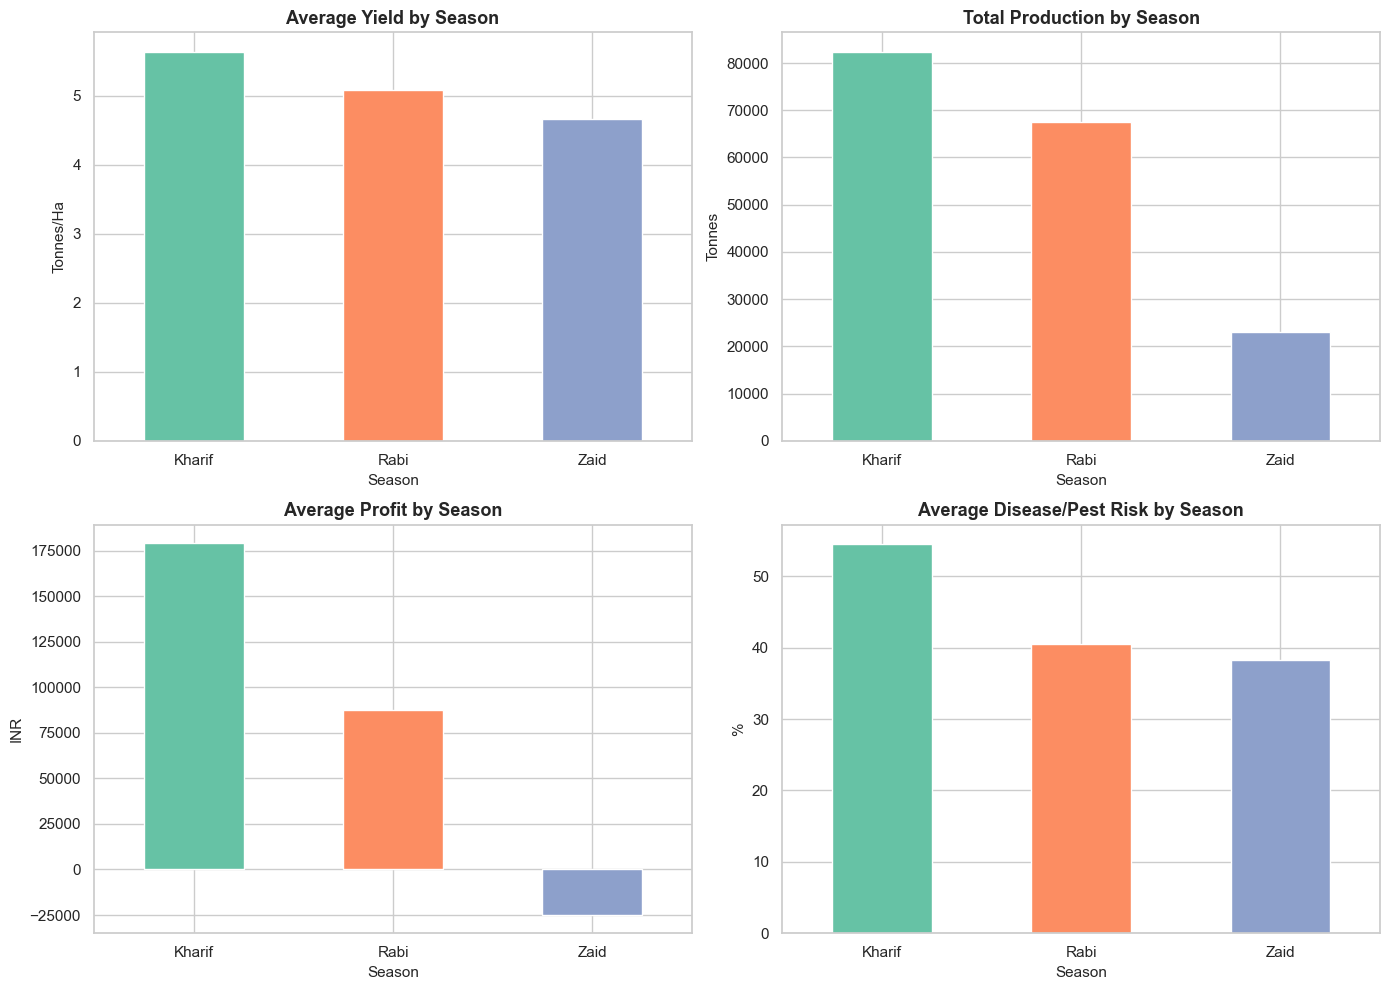

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

seasonal_summary['Avg_Yield'].plot(kind='bar', ax=axes[0,0], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[0,0].set_title('Average Yield by Season'); axes[0,0].set_ylabel('Tonnes/Ha'); axes[0,0].tick_params(rotation=0)

seasonal_summary['Total_Production'].plot(kind='bar', ax=axes[0,1], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[0,1].set_title('Total Production by Season'); axes[0,1].set_ylabel('Tonnes'); axes[0,1].tick_params(rotation=0)

seasonal_summary['Avg_Profit'].plot(kind='bar', ax=axes[1,0], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[1,0].set_title('Average Profit by Season'); axes[1,0].set_ylabel('INR'); axes[1,0].tick_params(rotation=0)

seasonal_summary['Avg_Disease_Pest_Risk'].plot(kind='bar', ax=axes[1,1], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[1,1].set_title('Average Disease/Pest Risk by Season'); axes[1,1].set_ylabel('%'); axes[1,1].tick_params(rotation=0)

plt.tight_layout()
plt.show()


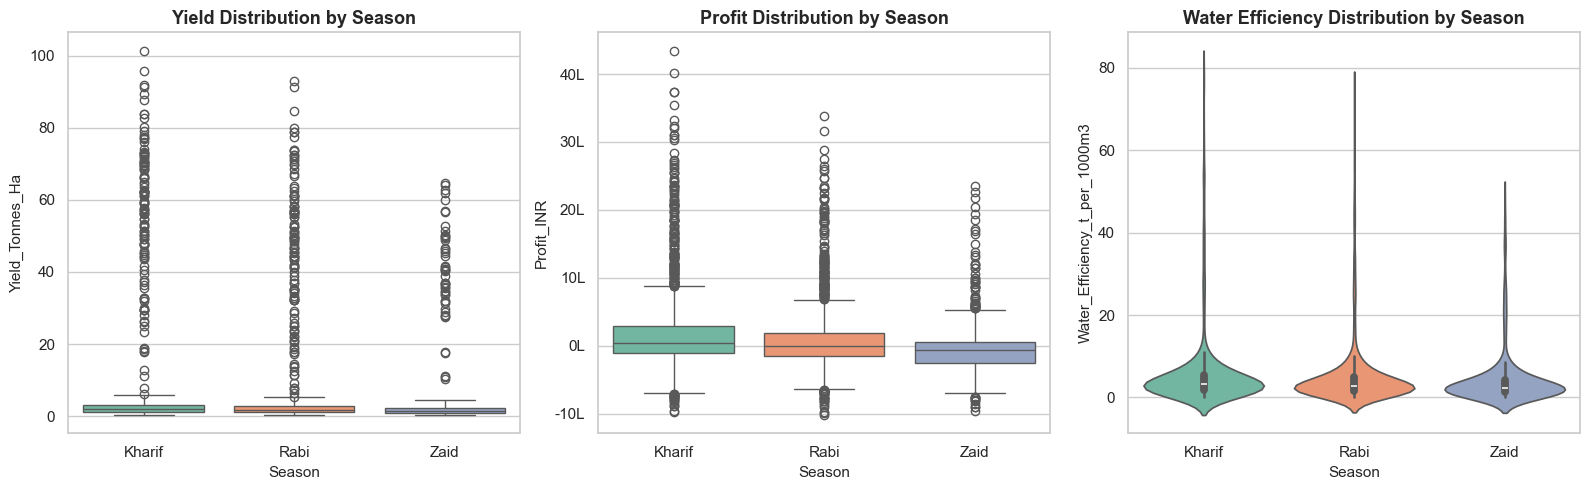

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[0])
axes[0].set_title('Yield Distribution by Season')

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[1])
axes[1].set_title('Profit Distribution by Season')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e5:.0f}L'))

sns.violinplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[2])
axes[2].set_title('Water Efficiency Distribution by Season')

plt.tight_layout()
plt.show()


In [30]:
best_yield_season = seasonal_summary['Avg_Yield'].idxmax()
best_profit_season = seasonal_summary['Avg_Profit'].idxmax()
best_production_season = seasonal_summary['Total_Production'].idxmax()
best_price_season = seasonal_summary['Avg_Market_Price'].idxmax()
most_water_season = seasonal_summary['Avg_Water_Used'].idxmax()
best_water_eff_season = seasonal_summary['Avg_Water_Efficiency'].idxmax()
highest_risk_season = seasonal_summary['Avg_Disease_Pest_Risk'].idxmax()

print(f"Season with the highest average yield            : {best_yield_season} ({seasonal_summary.loc[best_yield_season, 'Avg_Yield']} t/ha)")
print(f"Season with the highest average profit            : {best_profit_season} (INR {seasonal_summary.loc[best_profit_season, 'Avg_Profit']:,.0f})")
print(f"Season with the highest total production          : {best_production_season} ({seasonal_summary.loc[best_production_season, 'Total_Production']:,.0f} tonnes)")
print(f"Season with the highest average market price       : {best_price_season} (INR {seasonal_summary.loc[best_price_season, 'Avg_Market_Price']:,.0f}/tonne)")
print(f"Season using the most water on average            : {most_water_season} ({seasonal_summary.loc[most_water_season, 'Avg_Water_Used']:,.0f} m3)")
print(f"Season with the best water efficiency              : {best_water_eff_season} ({seasonal_summary.loc[best_water_eff_season, 'Avg_Water_Efficiency']} t/1000m3)")
print(f"Season with the highest average disease/pest risk : {highest_risk_season} ({seasonal_summary.loc[highest_risk_season, 'Avg_Disease_Pest_Risk']}%)")


Season with the highest average yield            : Kharif (5.64 t/ha)
Season with the highest average profit            : Kharif (INR 178,915)
Season with the highest total production          : Kharif (82,388 tonnes)
Season with the highest average market price       : Kharif (INR 44,851/tonne)
Season using the most water on average            : Zaid (6,420 m3)
Season with the best water efficiency              : Kharif (5.89 t/1000m3)
Season with the highest average disease/pest risk : Kharif (54.47%)


**Interpretation / Insight:** The summary table and charts above show, based purely on the calculated values, which season leads on each metric — yield, production, profitability, water use/efficiency and disease/pest risk (see the printed results directly above for the specific season names and figures for this dataset run). These per-metric leaders are not necessarily the same season, which is itself an important finding: a season that performs best on one dimension (e.g. yield) does not automatically perform best on another (e.g. profit or water efficiency). This is explored further in the sections that follow.


## Seasonal Environmental Conditions Analysis

Since environmental conditions are the primary driver of seasonal differences by definition, this section compares rainfall, temperature, humidity, sunlight and soil moisture across the three seasons.


In [31]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
env_summary = df_clean.groupby('Season')[env_cols].mean().reindex(SEASON_ORDER).round(2)
display(env_summary)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


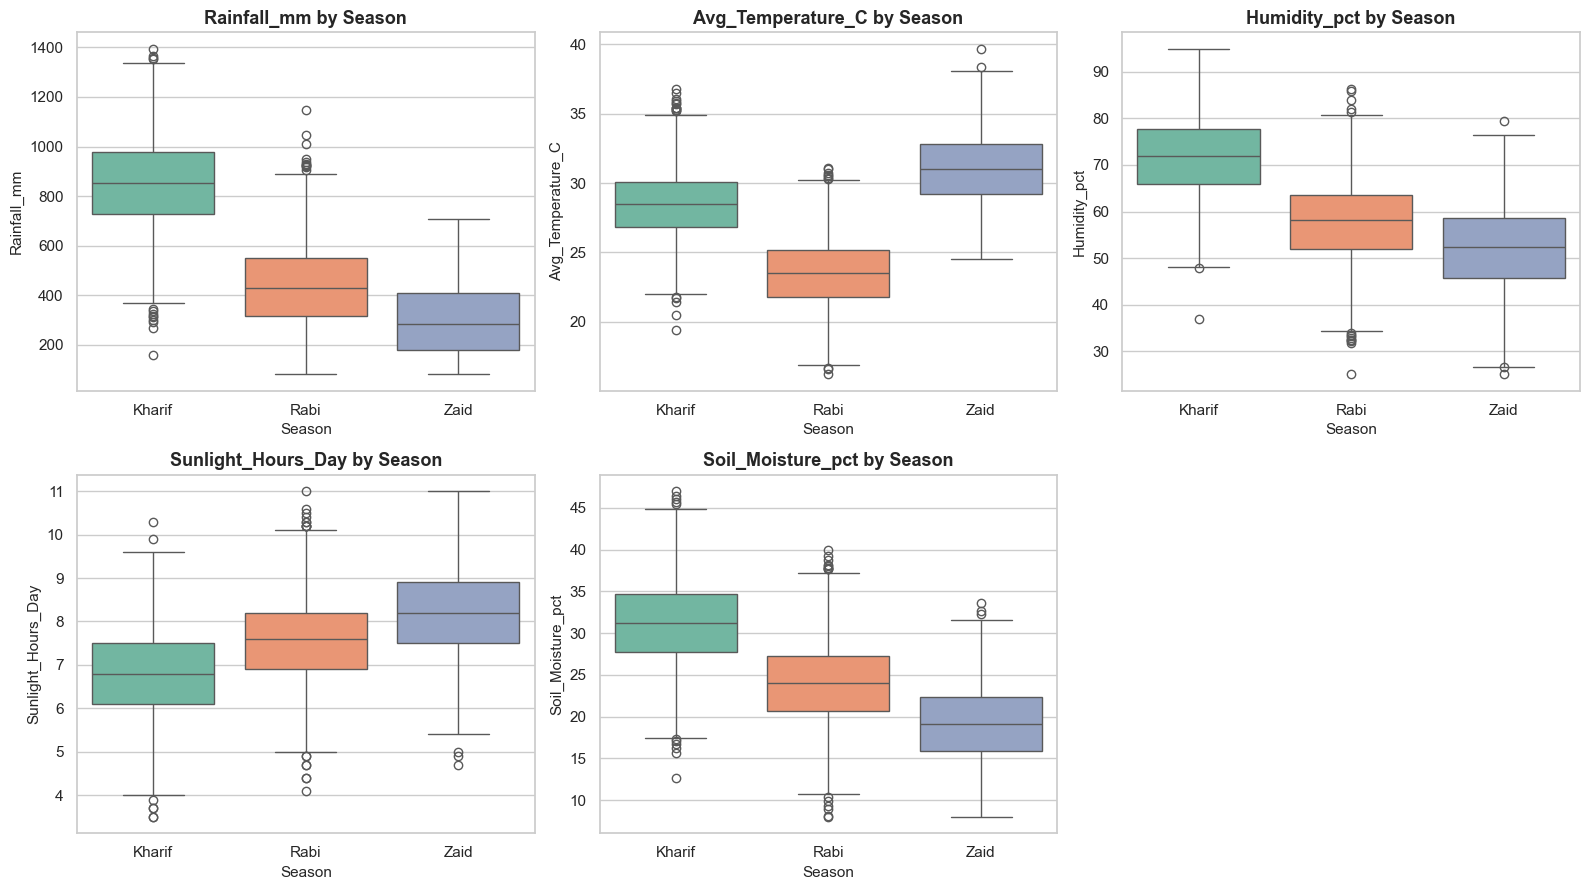

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df_clean, x='Season', y=col, order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[i])
    axes[i].set_title(f'{col} by Season')
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()


In [33]:
print("Season with highest average rainfall     :", env_summary['Rainfall_mm'].idxmax())
print("Season with highest average temperature   :", env_summary['Avg_Temperature_C'].idxmax())
print("Season with highest average humidity      :", env_summary['Humidity_pct'].idxmax())
print("Season with highest average sunlight hours:", env_summary['Sunlight_Hours_Day'].idxmax())
print("Season with highest average soil moisture :", env_summary['Soil_Moisture_pct'].idxmax())


Season with highest average rainfall     : Kharif
Season with highest average temperature   : Zaid
Season with highest average humidity      : Kharif
Season with highest average sunlight hours: Zaid
Season with highest average soil moisture : Kharif


In [34]:
# Yield column: use df_yield_observed so the Yield correlation is based only on observed yield values.
env_yield_corr = df_yield_observed[env_cols + ['Yield_Tonnes_Ha']].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha')
env_profit_corr = df_clean[env_cols + ['Profit_INR']].corr()['Profit_INR'].drop('Profit_INR')
env_perf_corr = pd.DataFrame({'Yield_Tonnes_Ha': env_yield_corr, 'Profit_INR': env_profit_corr})

print(f"Correlation of environmental variables with Yield (n={len(df_yield_observed)}, observed yield only) and Profit (n={len(df_clean)}):")
display(env_perf_corr.round(3))


Correlation of environmental variables with Yield (n=3968, observed yield only) and Profit (n=4000):


,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,0.028,0.106
Avg_Temperature_C,0.009,0.009
Humidity_pct,0.011,0.064
Sunlight_Hours_Day,-0.015,-0.055
Soil_Moisture_pct,0.010,0.092


**Interpretation / Insight:** The environmental profile differs across seasons as expected (rainfall, temperature, humidity, sunlight and soil moisture each peak in a different season — see the printed results above). The correlation table shows whether any single environmental variable is strongly linked to yield or profit at the individual-farm level; where correlations are weak, this indicates that seasonal performance differences are more likely driven by the **combination** of conditions (and by farming practices) rather than any one environmental factor alone.


## Crop Analysis

Agricultural performance is compared across the 8 crops present in the dataset, and then examined jointly with season to see whether crop performance shifts between seasons.


In [35]:
crop_summary = df_clean.groupby('Crop').agg(
    Num_Farms=('Farm_ID', 'count'),
    N_Yield_Observed=('Yield_Tonnes_Ha', 'count'),   # non-null yield count used for Avg/Median_Yield below
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Total_Production=('Production_Tonnes', 'sum'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Market_Price=('Market_Price_INR_Tonne', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Pest_Risk=('Disease_Pest_Risk_pct', 'mean'),
).sort_values('Avg_Profit', ascending=False).round(2)

display(crop_summary)


,Num_Farms,N_Yield_Observed,Avg_Yield,Median_Yield,Total_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Market_Price,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
Crop,,,,,,,,,,,
Sugarcane,305,303,46.94,48.03,119685.97,1371980.11,554792.13,817187.99,3490.25,30.48,45.40
Chilli,412,407,1.54,1.56,5101.75,1276777.23,525898.89,750878.34,103372.94,2.95,46.06
Cotton,508,504,1.23,1.24,4773.10,639423.08,514876.17,124546.92,67921.11,1.94,45.97
Groundnut,424,419,1.32,1.40,4094.07,542935.50,498077.38,44858.12,56310.06,3.15,46.29
Pulses,496,494,0.92,0.94,3671.10,528465.87,532703.92,-4238.05,71431.61,2.90,46.57
Maize,551,547,2.72,2.85,12001.40,457067.99,541046.32,-83978.33,20990.55,5.60,45.54
Rice,690,682,2.44,2.46,13309.15,423615.26,525828.76,-102213.50,22023.13,1.95,46.50
Wheat,614,612,2.11,2.22,10348.30,400104.89,523503.22,-123398.34,23829.43,4.63,47.85


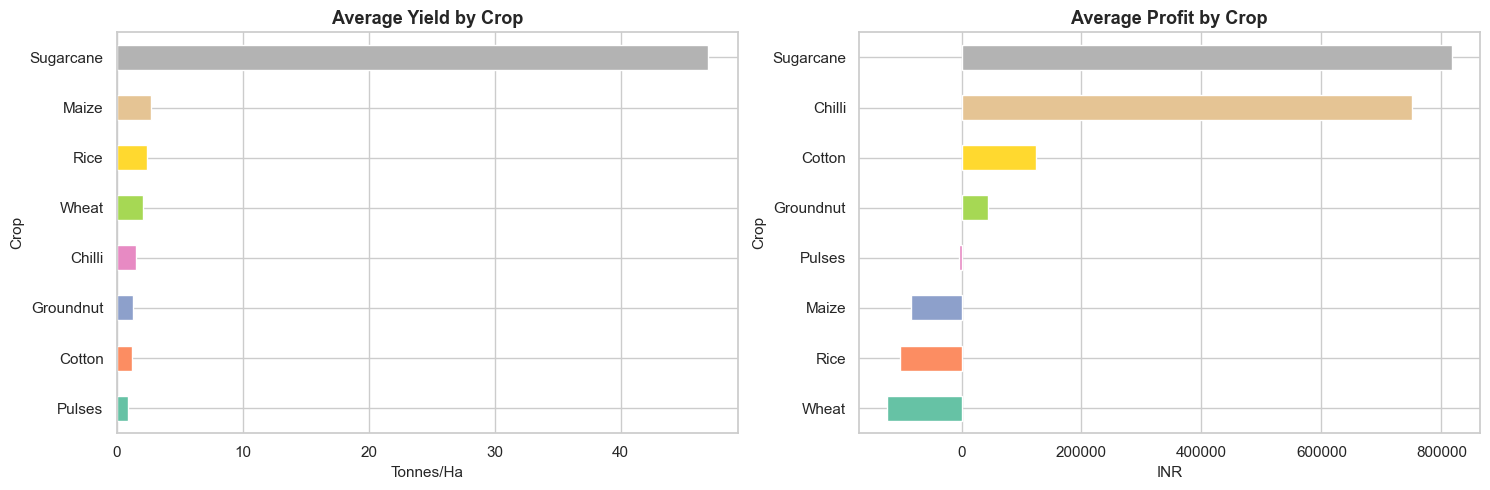

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

crop_summary['Avg_Yield'].sort_values().plot(kind='barh', ax=axes[0], color=sns.color_palette('Set2', 8))
axes[0].set_title('Average Yield by Crop'); axes[0].set_xlabel('Tonnes/Ha')

crop_summary['Avg_Profit'].sort_values().plot(kind='barh', ax=axes[1], color=sns.color_palette('Set2', 8))
axes[1].set_title('Average Profit by Crop'); axes[1].set_xlabel('INR')

plt.tight_layout()
plt.show()


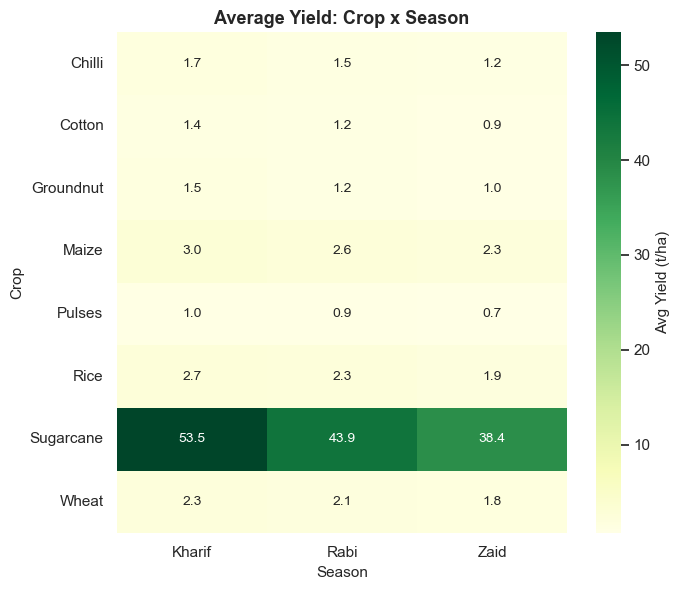

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


In [37]:
# Crop x Season -- average yield heatmap
crop_season_yield = df_clean.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha',
                                          aggfunc='mean', observed=True)[SEASON_ORDER].round(2)

plt.figure(figsize=(7, 6))
sns.heatmap(crop_season_yield, annot=True, fmt='.1f', cmap='YlGn', cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title('Average Yield: Crop x Season')
plt.tight_layout()
plt.show()

display(crop_season_yield)


In [38]:
# Crop x Season sample sizes -- to flag where interpretation should be cautious
crop_season_counts = df_clean.pivot_table(index='Crop', columns='Season', values='Farm_ID',
                                           aggfunc='count', observed=True)[SEASON_ORDER]
print("Number of farm records per Crop x Season combination (small cells should be interpreted cautiously):")
display(crop_season_counts)


Number of farm records per Crop x Season combination (small cells should be interpreted cautiously):


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


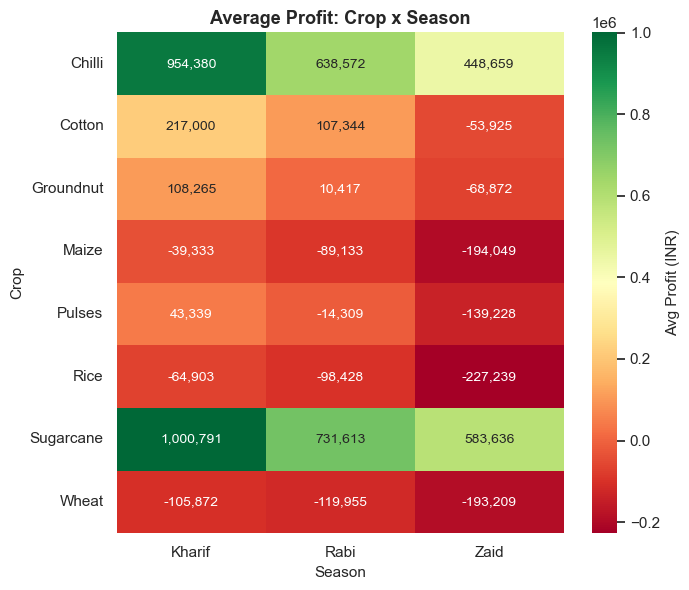

In [39]:
# Crop x Season -- profit
crop_season_profit = df_clean.pivot_table(index='Crop', columns='Season', values='Profit_INR',
                                           aggfunc='mean', observed=True)[SEASON_ORDER].round(0)

plt.figure(figsize=(7, 6))
sns.heatmap(crop_season_profit, annot=True, fmt=',.0f', cmap='RdYlGn', cbar_kws={'label': 'Avg Profit (INR)'})
plt.title('Average Profit: Crop x Season')
plt.tight_layout()
plt.show()


**Interpretation / Insight:** Crops differ substantially in yield and profitability (see the ranked table above), with `Sugarcane` standing out for very high yield per hectare — a genuine agronomic characteristic of the crop rather than a data error. The Crop × Season heatmaps show that most crops in this dataset are concentrated in specific seasons, so some Crop × Season cells have very few records (see the sample-size table) — any pattern in those cells should be treated as indicative rather than conclusive.


## State Analysis

Geographical (state-level) differences in agricultural performance, and whether seasonal patterns are consistent across states.


In [40]:
state_summary = df_clean.groupby('State').agg(
    Num_Farms=('Farm_ID', 'count'),
    N_Yield_Observed=('Yield_Tonnes_Ha', 'count'),   # non-null yield count used for Avg_Yield below
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Total_Production=('Production_Tonnes', 'sum'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Pest_Risk=('Disease_Pest_Risk_pct', 'mean'),
).sort_values('Avg_Profit', ascending=False).round(2)

display(state_summary)


,Num_Farms,N_Yield_Observed,Avg_Yield,Total_Production,Avg_Profit,Avg_Revenue,Avg_Cost,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
State,,,,,,,,,,
Punjab,484,484,6.12,25280.82,136025.64,686225.70,550200.07,6565.92,5.62,46.00
Maharashtra,512,510,5.03,22519.83,135428.86,650032.67,514603.81,5968.08,5.28,46.44
Karnataka,489,483,5.73,23341.30,119422.34,653426.18,534003.85,6414.33,5.56,46.06
Tamil Nadu,485,481,4.90,19807.58,117744.75,629093.42,511348.67,5775.22,5.31,46.28
Gujarat,488,483,5.70,23586.01,117568.24,654692.86,537124.62,6142.50,5.58,45.95
Telangana,516,511,5.08,20255.16,108829.62,628784.53,519954.92,5801.83,5.46,46.36
Madhya Pradesh,497,491,5.03,18667.08,86840.76,597558.36,510717.60,5663.92,5.27,47.08
Andhra Pradesh,529,525,4.65,19527.06,73453.53,606663.66,533210.13,6058.38,5.03,46.72


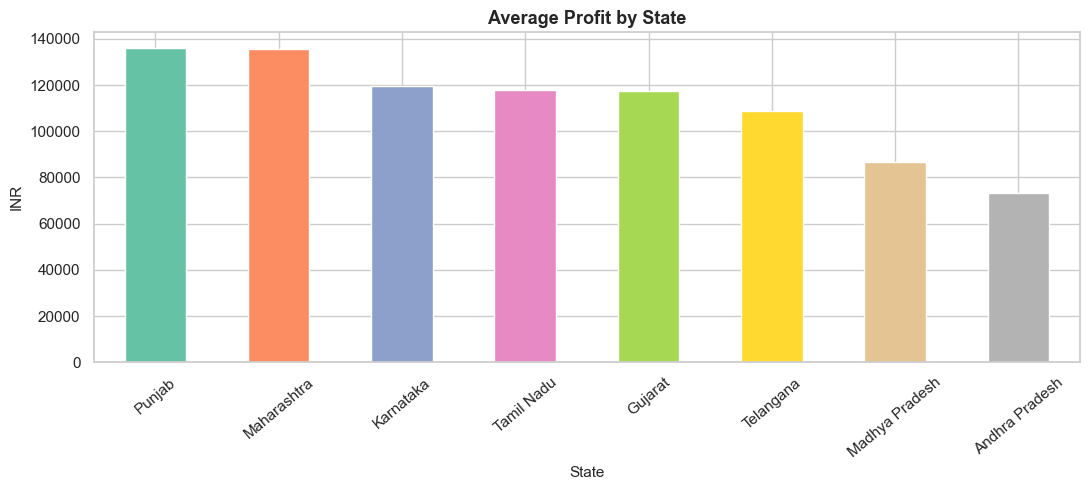

Note: states are ranked here by average profit alone for illustration. A state that leads on profit
may not also lead on yield or water efficiency -- see the full table above before drawing conclusions.


In [41]:
fig, ax = plt.subplots(figsize=(11, 5))
state_summary['Avg_Profit'].plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(state_summary)))
ax.set_title('Average Profit by State'); ax.set_ylabel('INR'); ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()

print("Note: states are ranked here by average profit alone for illustration. A state that leads on profit")
print("may not also lead on yield or water efficiency -- see the full table above before drawing conclusions.")


In [42]:
# Every state in this dataset has a substantial sample size (see Num_Farms above), but the check is
# still performed explicitly rather than assumed, so the ranking below is stated with its evidence base.
STATE_MIN_N = 30
min_state_n = state_summary['Num_Farms'].min()
states_above_threshold = state_summary[state_summary['Num_Farms'] >= STATE_MIN_N]

print(f"Smallest state sample size in the dataset: {min_state_n} records "
      f"({'above' if min_state_n >= STATE_MIN_N else 'below'} the {STATE_MIN_N}-record threshold used for ranking)")

top_state_by_profit = states_above_threshold['Avg_Profit'].idxmax()
print(f"\n'{top_state_by_profit}' has the highest average yield/profit among states with at least "
      f"{STATE_MIN_N} observations (n={states_above_threshold.loc[top_state_by_profit, 'Num_Farms']}), "
      f"with an average profit of INR {states_above_threshold.loc[top_state_by_profit, 'Avg_Profit']:,.0f}.")


Smallest state sample size in the dataset: 484 records (above the 30-record threshold used for ranking)

'Punjab' has the highest average yield/profit among states with at least 30 observations (n=484), with an average profit of INR 136,026.


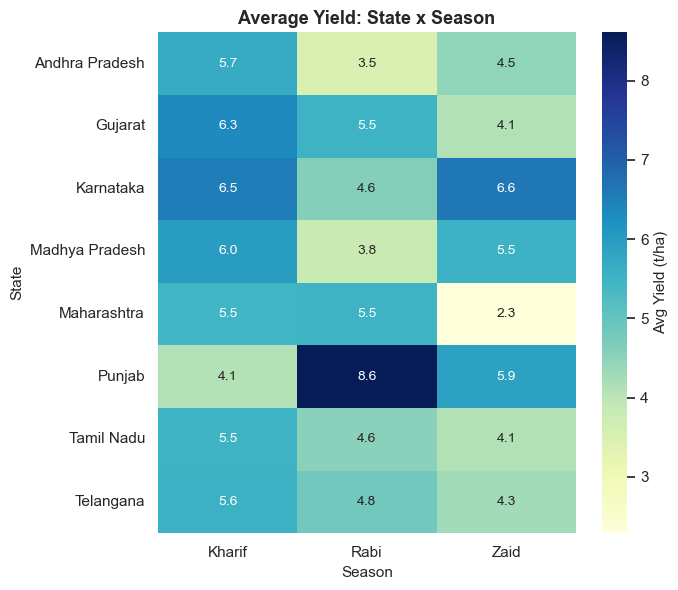

In [43]:
# State x Season -- average yield heatmap, to check consistency of seasonal patterns across states
state_season_yield = df_clean.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha',
                                           aggfunc='mean', observed=True)[SEASON_ORDER].round(2)

plt.figure(figsize=(7, 6))
sns.heatmap(state_season_yield, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title('Average Yield: State x Season')
plt.tight_layout()
plt.show()


In [44]:
# Check whether the best-performing season is the same in every state
best_season_per_state = state_season_yield.idxmax(axis=1)
print("Best-yielding season per state:")
print(best_season_per_state)
print()
print(f"Number of states sharing the single most common best season: "
      f"{best_season_per_state.value_counts().max()} out of {len(best_season_per_state)}")


Best-yielding season per state:
State
Andhra Pradesh    Kharif
Gujarat           Kharif
Karnataka           Zaid
Madhya Pradesh    Kharif
Maharashtra         Rabi
Punjab              Rabi
Tamil Nadu        Kharif
Telangana         Kharif
dtype: object

Number of states sharing the single most common best season: 5 out of 8


**Interpretation / Insight:** Average profit and yield vary noticeably by state (see the ranked table above). The State × Season heatmap and the best-season-per-state check show whether the season that produces the highest yield is consistent across states or whether it varies geographically — this distinction matters for planners deciding whether a single national seasonal recommendation makes sense, or whether state-specific guidance is needed.


## District Analysis

District-level performance is examined, with caution around districts that have few observations.


In [45]:
district_counts = df_clean['District'].value_counts()
print("Number of records per district:")
print(district_counts)


Number of records per district:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64


In [46]:
district_summary = df_clean.groupby('District').agg(
    Num_Farms=('Farm_ID', 'count'),
    N_Yield_Observed=('Yield_Tonnes_Ha', 'count'),   # non-null yield count used for Avg_Yield below
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Pest_Risk=('Disease_Pest_Risk_pct', 'mean'),
).round(2)

DISTRICT_MIN_N = 30
districts_above_threshold = district_summary[district_summary['Num_Farms'] >= DISTRICT_MIN_N]
print(f"Districts with at least {DISTRICT_MIN_N} observations: {len(districts_above_threshold)} of {len(district_summary)}\n")

print(f"Top 5 districts by average yield (n >= {DISTRICT_MIN_N}):")
display(districts_above_threshold.sort_values('Avg_Yield', ascending=False).head(5))

print(f"Top 5 districts by average profit (n >= {DISTRICT_MIN_N}):")
display(districts_above_threshold.sort_values('Avg_Profit', ascending=False).head(5))

print(f"Top 5 districts by average water efficiency (n >= {DISTRICT_MIN_N}):")
display(districts_above_threshold.sort_values('Avg_Water_Efficiency', ascending=False).head(5))

print(f"Top 5 districts by average disease/pest risk (n >= {DISTRICT_MIN_N}):")
display(districts_above_threshold.sort_values('Avg_Disease_Pest_Risk', ascending=False).head(5))


Districts with at least 30 observations: 10 of 10

Top 5 districts by average yield (n >= 30):


,Num_Farms,N_Yield_Observed,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
District,,,,,,
Rajkot,401,400,6.03,119463.28,5.67,45.92
Ludhiana,427,422,5.85,87590.83,5.80,46.58
Nalgonda,415,412,5.83,131125.84,5.56,45.05
Warangal,422,417,5.55,166449.96,5.86,46.69
Guntur,390,387,5.50,116411.42,5.75,45.71


Top 5 districts by average profit (n >= 30):


,Num_Farms,N_Yield_Observed,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
District,,,,,,
Warangal,422,417,5.55,166449.96,5.86,46.69
Nalgonda,415,412,5.83,131125.84,5.56,45.05
Raichur,386,381,4.98,125172.70,5.31,47.03
Rajkot,401,400,6.03,119463.28,5.67,45.92
Guntur,390,387,5.50,116411.42,5.75,45.71


Top 5 districts by average water efficiency (n >= 30):


,Num_Farms,N_Yield_Observed,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
District,,,,,,
Warangal,422,417,5.55,166449.96,5.86,46.69
Ludhiana,427,422,5.85,87590.83,5.80,46.58
Guntur,390,387,5.50,116411.42,5.75,45.71
Rajkot,401,400,6.03,119463.28,5.67,45.92
Nalgonda,415,412,5.83,131125.84,5.56,45.05


Top 5 districts by average disease/pest risk (n >= 30):


,Num_Farms,N_Yield_Observed,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
District,,,,,,
Indore,392,392,4.88,90421.34,5.04,47.07
Raichur,386,381,4.98,125172.70,5.31,47.03
Nashik,371,369,4.88,94910.17,5.02,46.85
Warangal,422,417,5.55,166449.96,5.86,46.69
Ludhiana,427,422,5.85,87590.83,5.80,46.58


**Interpretation / Insight:** With only 10 districts each pooling several hundred records (across multiple states), district-level averages are based on reasonably sized samples, but the same district name can appear under different states in this dataset, so district-level figures here should be read as an overall pattern rather than a precise administrative-boundary analysis. This is noted again in the Limitations section.


## Irrigation Method Analysis

Comparing the four irrigation methods present in the dataset — Drip, Flood, Rainfed and Sprinkler — on yield, production, profit, water use and disease/pest risk. Associations are described descriptively; **no causal claims are made**, since irrigation method is not randomly assigned in this dataset.


In [47]:
irrigation_summary = df_clean.groupby('Irrigation_Method').agg(
    Num_Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Pest_Risk=('Disease_Pest_Risk_pct', 'mean'),
).sort_values('Avg_Water_Efficiency', ascending=False).round(2)

display(irrigation_summary)


,Num_Farms,Avg_Yield,Avg_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Pest_Risk
Irrigation_Method,,,,,,,
Rainfed,1041,4.61,36.61,79050.37,3549.55,7.56,46.49
Drip,915,6.62,57.99,219626.00,5918.75,6.27,45.79
Sprinkler,734,5.19,42.34,91121.08,6208.26,4.67,46.48
Flood,1310,4.90,38.73,73354.02,8026.47,3.44,46.60


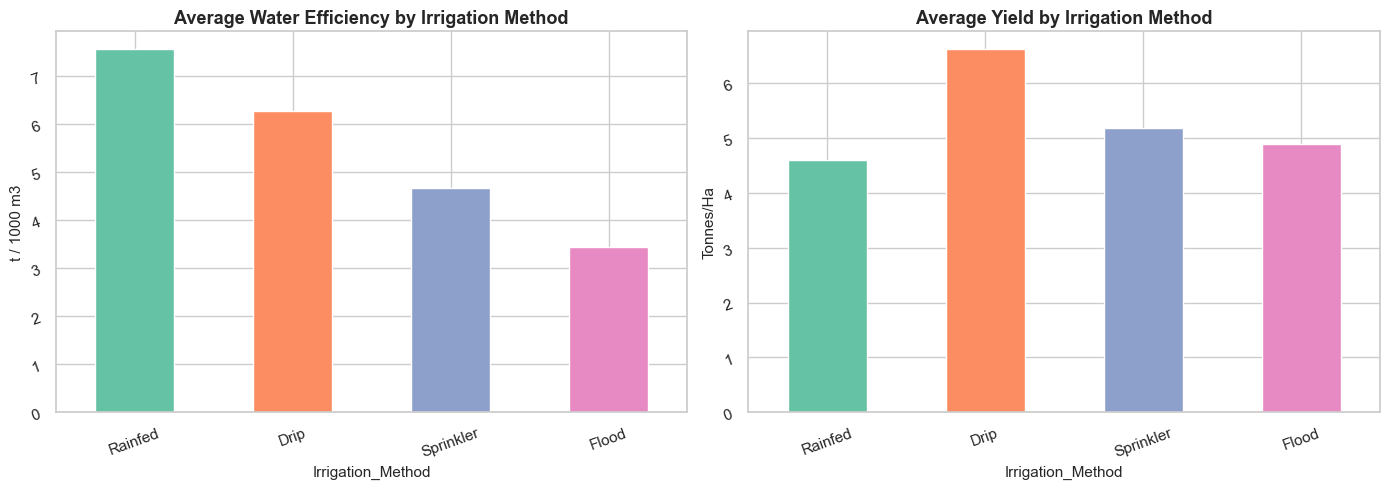

The dataset shows an association between the 'Rainfed' irrigation method and the highest average water efficiency.


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

irrigation_summary['Avg_Water_Efficiency'].plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', 4))
axes[0].set_title('Average Water Efficiency by Irrigation Method'); axes[0].set_ylabel('t / 1000 m3'); axes[0].tick_params(rotation=20)

irrigation_summary['Avg_Yield'].plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2', 4))
axes[1].set_title('Average Yield by Irrigation Method'); axes[1].set_ylabel('Tonnes/Ha'); axes[1].tick_params(rotation=20)

plt.tight_layout()
plt.show()

best_irrig_efficiency = irrigation_summary['Avg_Water_Efficiency'].idxmax()
print(f"The dataset shows an association between the '{best_irrig_efficiency}' irrigation method and the highest average water efficiency.")


**Interpretation / Insight:** The irrigation methods differ in average water efficiency and yield (see table above). The method with the highest average water efficiency is identified above using the phrase *"the dataset shows an association"* deliberately, since irrigation method may itself be correlated with crop choice, region and season rather than being an independent cause of the outcome.


## Resource (Input) Usage Analysis

Examining nitrogen, phosphorus, potassium, fertilizer, pesticide and water usage, and how they relate to yield, production, profit, water efficiency and disease/pest risk.


In [49]:
resource_cols = ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3']
resource_season_summary = df_clean.groupby('Season')[resource_cols].mean().reindex(SEASON_ORDER).round(2)
display(resource_season_summary)


,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


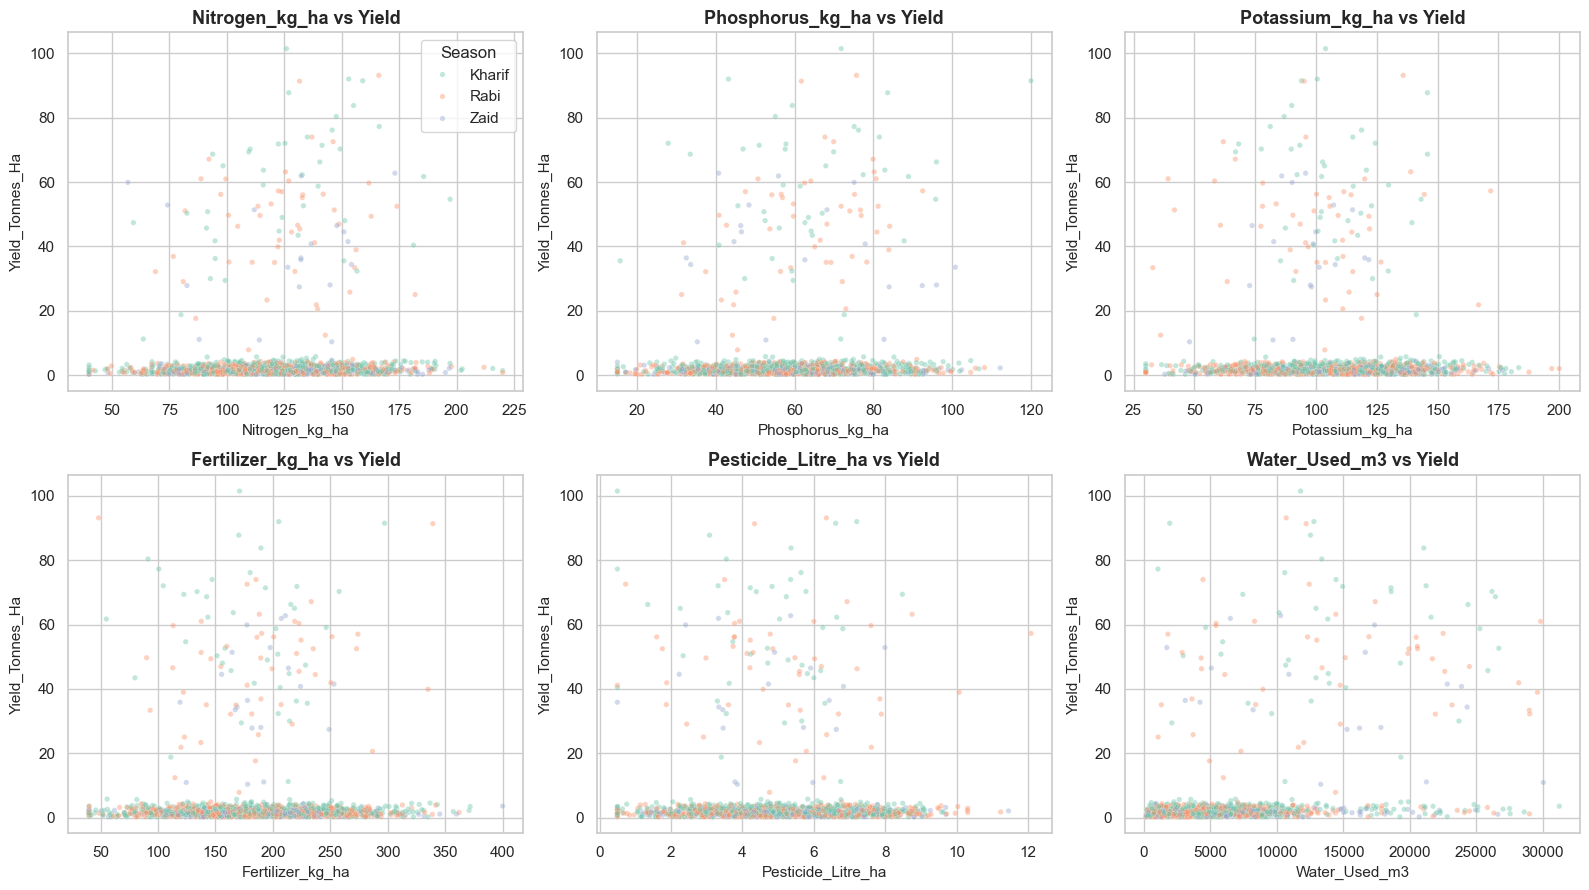

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
outcome = 'Yield_Tonnes_Ha'
for i, col in enumerate(resource_cols):
    sns.scatterplot(data=df_yield_observed.sample(min(1500, len(df_yield_observed)), random_state=42), x=col, y=outcome,
                     hue='Season', hue_order=SEASON_ORDER, palette=SEASON_PALETTE, alpha=0.4, s=15, ax=axes[i], legend=(i==0))
    axes[i].set_title(f'{col} vs Yield')
plt.tight_layout()
plt.show()


In [51]:
# Yield-involving correlations computed from df_yield_observed; the rest from df_clean.
resource_yield_corr = df_yield_observed[resource_cols + ['Yield_Tonnes_Ha']].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha')
resource_other_corr = df_clean[resource_cols + ['Production_Tonnes', 'Profit_INR',
                                                 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']].corr()
resource_perf_corr = resource_other_corr.loc[resource_cols, ['Production_Tonnes', 'Profit_INR',
                                                               'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']].copy()
resource_perf_corr.insert(0, 'Yield_Tonnes_Ha', resource_yield_corr)

print(f"Yield column uses n={len(df_yield_observed)} (observed yield only); other columns use n={len(df_clean)}.")
display(resource_perf_corr.round(3))


Yield column uses n=3968 (observed yield only); other columns use n=4000.


,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Nitrogen_kg_ha,0.054,0.048,0.085,0.055,-0.012
Phosphorus_kg_ha,0.048,0.035,0.050,0.057,0.032
Potassium_kg_ha,0.004,0.004,0.031,0.007,0.013
Fertilizer_kg_ha,0.001,0.001,-0.074,0.005,0.018
Pesticide_Litre_ha,-0.008,-0.009,-0.026,-0.006,-0.465
Water_Used_m3,0.389,0.516,0.190,0.217,0.011


**Interpretation / Insight:** The correlation table shows whether more input (fertilizer, pesticide, water, nutrients) is associated with better outcomes in this dataset. Where correlations with yield or profit are weak or even negative, this indicates that **more input does not automatically mean better performance** — over-application can raise cost and disease/pest risk without a proportional gain in output, which is consistent with real agronomic practice (diminishing/negative returns beyond an optimal input level).


## Soil & Nutrient Condition Analysis

Examining soil pH, soil moisture and nutrient levels (N, P, K), their relationship with yield/production/profit, and whether they vary by season or crop.


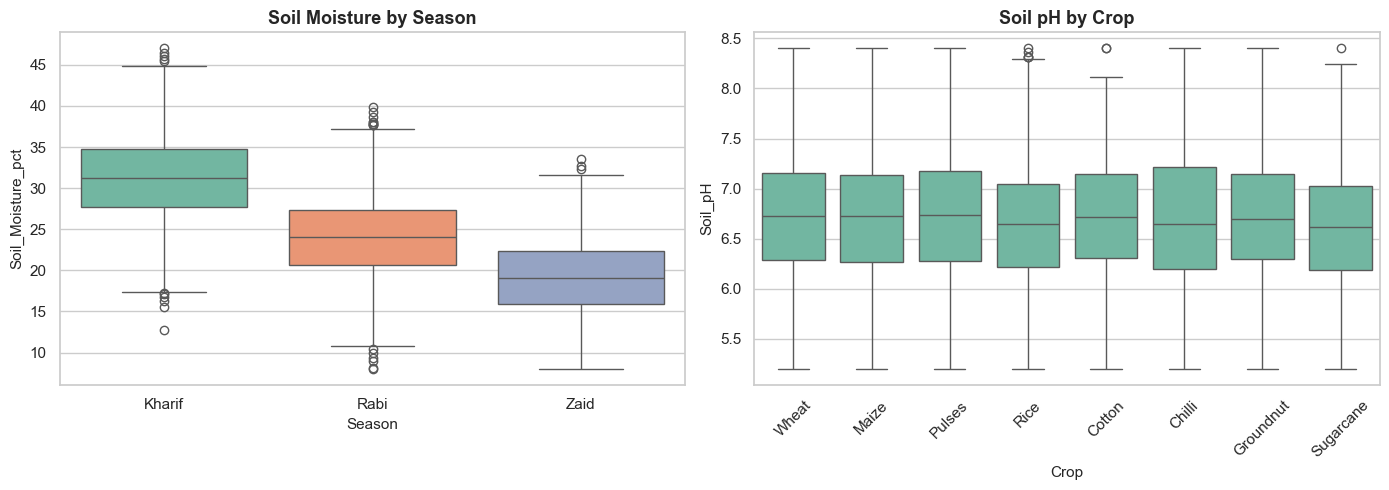

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='Season', y='Soil_Moisture_pct', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[0])
axes[0].set_title('Soil Moisture by Season')

sns.boxplot(data=df_clean, x='Crop', y='Soil_pH', ax=axes[1])
axes[1].set_title('Soil pH by Crop')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [53]:
soil_nutrient_cols = ['Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']
soil_yield_corr = df_yield_observed[soil_nutrient_cols + ['Yield_Tonnes_Ha']].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(ascending=False)

print(f"Correlation of soil/nutrient variables with Yield (n={len(df_yield_observed)}, observed yield only, strongest first):")
display(soil_yield_corr.round(3))

strongest_soil_var = soil_yield_corr.abs().idxmax()
print(f"\nThe soil/nutrient variable with the strongest linear relationship with yield is: {strongest_soil_var} (r = {soil_yield_corr[strongest_soil_var]:.3f})")


Correlation of soil/nutrient variables with Yield (n=3968, observed yield only, strongest first):


Nitrogen_kg_ha       0.054
Phosphorus_kg_ha     0.048
Soil_Moisture_pct    0.010
Potassium_kg_ha      0.004
Soil_pH             -0.021
Name: Yield_Tonnes_Ha, dtype: float64


The soil/nutrient variable with the strongest linear relationship with yield is: Nitrogen_kg_ha (r = 0.054)


**Interpretation / Insight:** Soil moisture differs by season as expected from seasonal rainfall patterns, and soil pH shows some variation across crops (visible in the box plots above). The correlation ranking identifies which single soil/nutrient variable is most closely (linearly) associated with yield in this dataset — this is a **correlational**, not causal, relationship, since soil conditions, crop choice and season are themselves interrelated.


## Yield Analysis

A focused, detailed look at `Yield_Tonnes_Ha` — its central tendency, spread, skewness and unusual observations. This section uses **`df_yield_observed`** throughout (yield's own missing records are, by definition, excluded rather than imputed).


In [54]:
yield_stats = df_yield_observed['Yield_Tonnes_Ha'].describe()
print(f"Yield_Tonnes_Ha summary statistics (n={len(df_yield_observed)}, observed values only):")
print(yield_stats.round(2))
print(f"\nSkewness: {df_yield_observed['Yield_Tonnes_Ha'].skew():.2f}")


Yield_Tonnes_Ha summary statistics (n=3968, observed values only):
count    3968.00
mean        5.27
std        13.36
min         0.30
25%         1.05
50%         1.74
75%         2.84
max       101.44
Name: Yield_Tonnes_Ha, dtype: float64

Skewness: 4.04


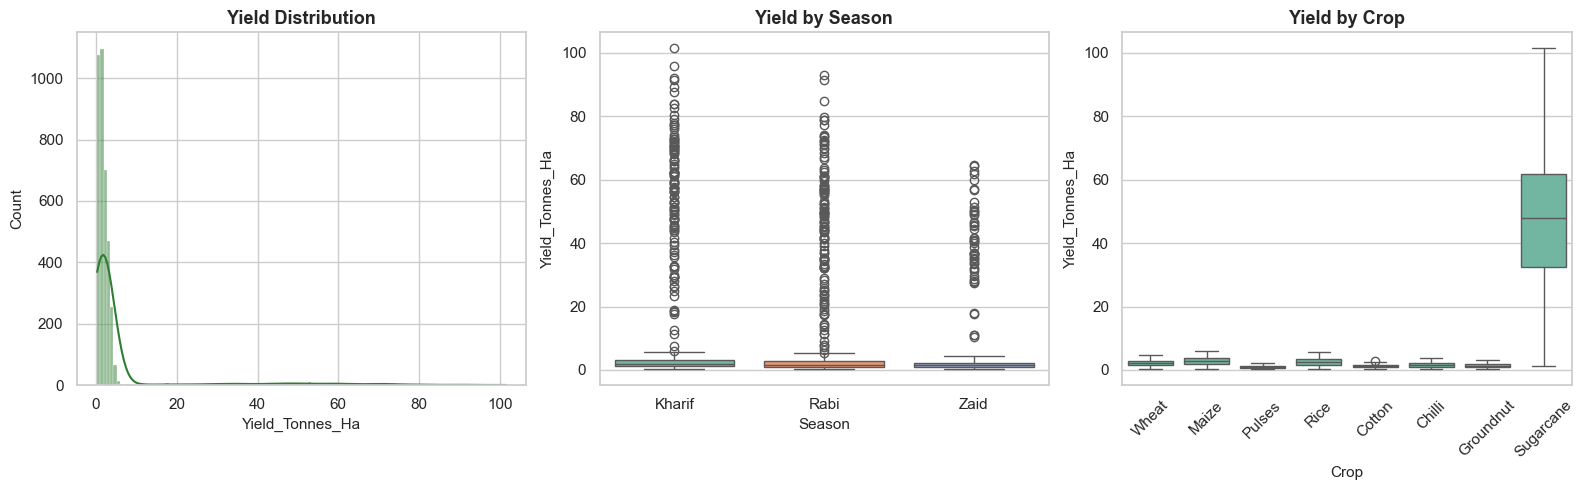

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df_yield_observed['Yield_Tonnes_Ha'], kde=True, ax=axes[0], color='#2E7D32')
axes[0].set_title('Yield Distribution')

sns.boxplot(data=df_yield_observed, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[1])
axes[1].set_title('Yield by Season')

sns.boxplot(data=df_yield_observed, x='Crop', y='Yield_Tonnes_Ha', ax=axes[2])
axes[2].set_title('Yield by Crop'); axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [56]:
print("Top 5 highest-yield records:")
display(df_yield_observed.nlargest(5, 'Yield_Tonnes_Ha')[['Farm_ID', 'Crop', 'Season', 'State', 'Yield_Tonnes_Ha']])

print("\nTop 5 lowest-yield records:")
display(df_yield_observed.nsmallest(5, 'Yield_Tonnes_Ha')[['Farm_ID', 'Crop', 'Season', 'State', 'Yield_Tonnes_Ha']])


Top 5 highest-yield records:


,Farm_ID,Crop,Season,State,Yield_Tonnes_Ha
1715,SF11716,Sugarcane,Kharif,Gujarat,101.44
3423,SF13424,Sugarcane,Kharif,Andhra Pradesh,95.79
3525,SF13526,Sugarcane,Rabi,Andhra Pradesh,93.13
1464,SF11465,Sugarcane,Kharif,Gujarat,91.98
3523,SF13524,Sugarcane,Kharif,Karnataka,91.46



Top 5 lowest-yield records:


,Farm_ID,Crop,Season,State,Yield_Tonnes_Ha
1,SF10002,Maize,Kharif,Maharashtra,0.3
12,SF10013,Wheat,Rabi,Punjab,0.3
25,SF10026,Pulses,Kharif,Gujarat,0.3
31,SF10032,Groundnut,Zaid,Madhya Pradesh,0.3
40,SF10041,Pulses,Kharif,Karnataka,0.3


**Interpretation / Insight:** Yield is right-skewed (see the skewness value printed above), meaning most farms cluster at moderate yield levels while a smaller number achieve much higher yield. As seen in the by-crop box plot, the highest-yield records are dominated by `Sugarcane`, which is agronomically expected to have far higher yield-per-hectare than grain or pulse crops — so these are legitimate high performers, not data errors.


## Production Analysis

Analysing `Production_Tonnes` and its relationship with farm area and yield, and clarifying the difference between yield (per-hectare output) and production (total output).


In [57]:
production_by_season = df_clean.groupby('Season')['Production_Tonnes'].agg(['sum', 'mean', 'median']).reindex(SEASON_ORDER).round(2)
production_by_crop = df_clean.groupby('Crop')['Production_Tonnes'].agg(['sum', 'mean']).sort_values('sum', ascending=False).round(2)
production_by_irrigation = df_clean.groupby('Irrigation_Method')['Production_Tonnes'].agg(['sum', 'mean']).round(2)

print("Production by Season:"); display(production_by_season)
print("Production by Crop:"); display(production_by_crop)
print("Production by Irrigation Method:"); display(production_by_irrigation)


Production by Season:


,sum,mean,median
Season,,,
Kharif,82387.61,46.31,13.24
Rabi,67498.88,41.49,11.08
Zaid,23098.35,38.89,9.97


Production by Crop:


,sum,mean
Crop,,
Sugarcane,119685.97,392.41
Rice,13309.15,19.29
Maize,12001.40,21.78
Wheat,10348.30,16.85
Chilli,5101.75,12.38
Cotton,4773.10,9.40
Groundnut,4094.07,9.66
Pulses,3671.10,7.40


Production by Irrigation Method:


,sum,mean
Irrigation_Method,,
Drip,53064.77,57.99
Flood,50738.41,38.73
Rainfed,38105.84,36.61
Sprinkler,31075.82,42.34


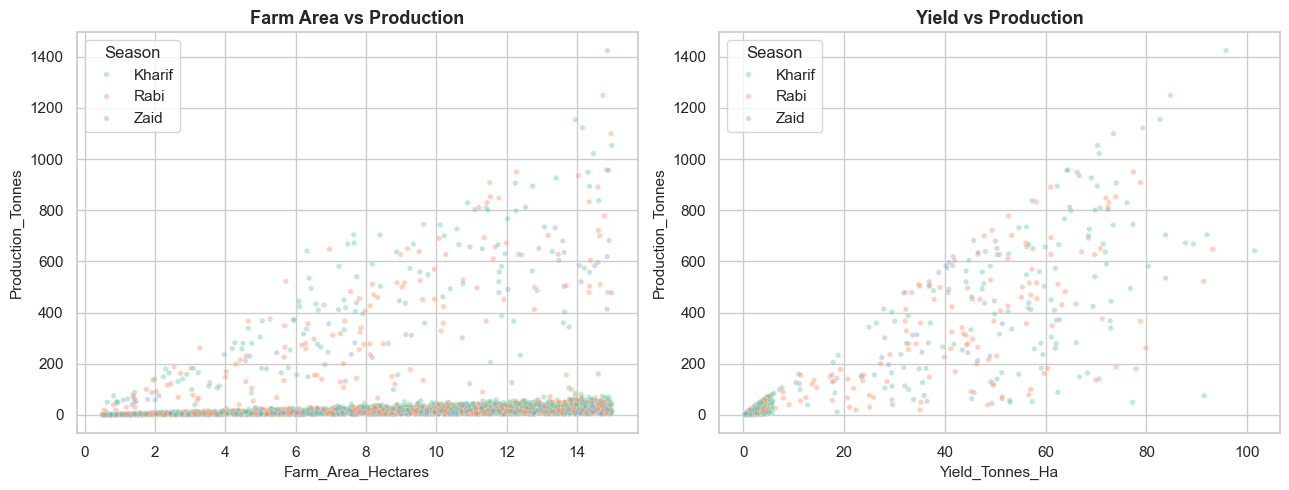

Correlation (Farm Area, Production)              : 0.198  (n=4000)
Correlation (Yield, Production, observed yield)  : 0.885  (n=3968)


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df_clean, x='Farm_Area_Hectares', y='Production_Tonnes', hue='Season',
                 hue_order=SEASON_ORDER, palette=SEASON_PALETTE, alpha=0.4, s=15, ax=axes[0])
axes[0].set_title('Farm Area vs Production')

sns.scatterplot(data=df_yield_observed, x='Yield_Tonnes_Ha', y='Production_Tonnes', hue='Season',
                 hue_order=SEASON_ORDER, palette=SEASON_PALETTE, alpha=0.4, s=15, ax=axes[1])
axes[1].set_title('Yield vs Production')

plt.tight_layout()
plt.show()

area_prod_corr = df_clean['Farm_Area_Hectares'].corr(df_clean['Production_Tonnes'])
yield_prod_corr = df_yield_observed['Yield_Tonnes_Ha'].corr(df_yield_observed['Production_Tonnes'])
print(f"Correlation (Farm Area, Production)              : {area_prod_corr:.3f}  (n={len(df_clean)})")
print(f"Correlation (Yield, Production, observed yield)  : {yield_prod_corr:.3f}  (n={len(df_yield_observed)})")


**Interpretation / Insight:** `Yield_Tonnes_Ha` measures productivity **per unit of land**, while `Production_Tonnes` measures the **total output** of a farm — a small, highly productive farm can have high yield but modest total production, and vice versa. The correlation values above quantify how strongly each of farm area and yield individually relates to total production in this dataset.


## Economic Performance Analysis

Comparing market price, cost, revenue and profit across seasons, crops, states and irrigation methods, using the profit-margin and per-hectare features engineered earlier.

**Handling of negative profit:** `Profit_INR` legitimately contains both positive and negative values in this dataset — confirmed loss-making farms are **kept in every calculation below** (means, medians, correlations, tests), not treated as outliers or removed. Loss-making operations are themselves an analytically important part of seasonal economic performance and are examined directly in the Outlier Analysis section later in this notebook.


In [59]:
econ_by_season = df_clean.groupby('Season').agg(
    Avg_Revenue=('Revenue_INR', 'mean'), Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'), Avg_Profit_Margin=('Profit_Margin_pct', 'mean'),
    Avg_Revenue_per_Ha=('Revenue_per_Hectare', 'mean'), Avg_Profit_per_Ha=('Profit_per_Hectare', 'mean'),
).reindex(SEASON_ORDER).round(2)
display(econ_by_season)


,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Profit_Margin,Avg_Revenue_per_Ha,Avg_Profit_per_Ha
Season,,,,,,
Kharif,710719.06,531804.41,178914.65,-38.64,88782.79,21881.81
Rabi,601526.05,513836.58,87689.47,-44.27,76656.92,10361.68
Zaid,519171.90,543976.73,-24804.82,-69.35,64301.42,-2636.52


In [60]:
econ_by_crop = df_clean.groupby('Crop').agg(
    Avg_Revenue=('Revenue_INR', 'mean'), Avg_Cost=('Total_Cost_INR', 'mean'), Avg_Profit=('Profit_INR', 'mean'),
).round(2)

most_profitable_crop = econ_by_crop['Avg_Profit'].idxmax()
highest_revenue_crop = econ_by_crop['Avg_Revenue'].idxmax()
highest_cost_crop = econ_by_crop['Avg_Cost'].idxmax()
lowest_profit_crop = econ_by_crop['Avg_Profit'].idxmin()

print(f"Most profitable crop (avg profit)  : {most_profitable_crop}")
print(f"Highest-revenue crop (avg revenue) : {highest_revenue_crop}")
print(f"Highest-cost crop (avg cost)       : {highest_cost_crop}")
print(f"Lowest-profit crop (avg profit)    : {lowest_profit_crop}")
display(econ_by_crop.sort_values('Avg_Profit', ascending=False))


Most profitable crop (avg profit)  : Sugarcane
Highest-revenue crop (avg revenue) : Sugarcane
Highest-cost crop (avg cost)       : Sugarcane
Lowest-profit crop (avg profit)    : Wheat


,Avg_Revenue,Avg_Cost,Avg_Profit
Crop,,,
Sugarcane,1371980.11,554792.13,817187.99
Chilli,1276777.23,525898.89,750878.34
Cotton,639423.08,514876.17,124546.92
Groundnut,542935.50,498077.38,44858.12
Pulses,528465.87,532703.92,-4238.05
Maize,457067.99,541046.32,-83978.33
Rice,423615.26,525828.76,-102213.50
Wheat,400104.89,523503.22,-123398.34


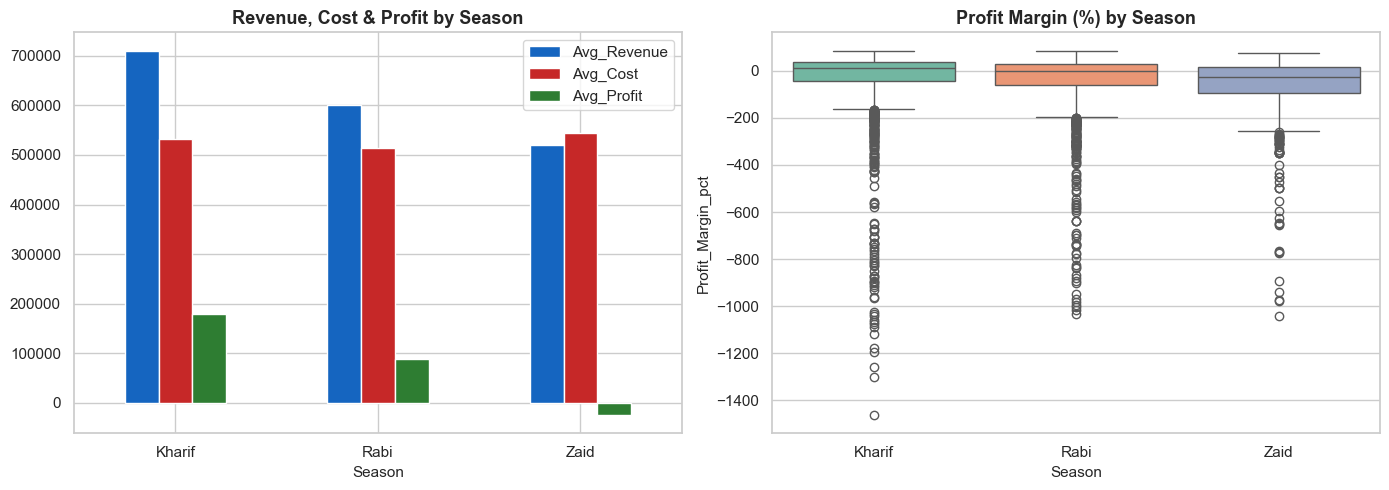

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

econ_by_season[['Avg_Revenue', 'Avg_Cost', 'Avg_Profit']].plot(kind='bar', ax=axes[0],
                                                                 color=['#1565C0', '#C62828', '#2E7D32'])
axes[0].set_title('Revenue, Cost & Profit by Season'); axes[0].tick_params(rotation=0)

sns.boxplot(data=df_clean, x='Season', y='Profit_Margin_pct', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[1])
axes[1].set_title('Profit Margin (%) by Season')

plt.tight_layout()
plt.show()


**Interpretation / Insight:** The season and crop leading on **revenue** are not necessarily the same as the season/crop leading on **profit**, since profit also depends on cost (see the printed comparisons above). This distinction is important for practical planning: chasing the highest-revenue option without accounting for cost can lead to a lower-profit outcome.


## Market Price Analysis

Examining `Market_Price_INR_Tonne` across seasons, crops and states, and whether higher market price is associated with higher revenue or profit (noting that revenue/profit also depend on production volume and cost).


In [62]:
price_by_season = df_clean.groupby('Season')['Market_Price_INR_Tonne'].mean().reindex(SEASON_ORDER).round(2)
price_by_crop = df_clean.groupby('Crop')['Market_Price_INR_Tonne'].mean().sort_values(ascending=False).round(2)
price_by_state = df_clean.groupby('State')['Market_Price_INR_Tonne'].mean().sort_values(ascending=False).round(2)

print("Average market price by season:"); print(price_by_season)
print("\nAverage market price by crop:"); print(price_by_crop)
print("\nAverage market price by state:"); print(price_by_state)


Average market price by season:
Season
Kharif    44850.91
Rabi      44747.97
Zaid      44212.03
Name: Market_Price_INR_Tonne, dtype: float64

Average market price by crop:
Crop
Chilli       103372.94
Pulses        71431.61
Cotton        67921.11
Groundnut     56310.06
Wheat         23829.43
Rice          22023.13
Maize         20990.55
Sugarcane      3490.25
Name: Market_Price_INR_Tonne, dtype: float64

Average market price by state:
State
Tamil Nadu        45767.64
Andhra Pradesh    45749.46
Maharashtra       44835.25
Madhya Pradesh    44771.17
Punjab            44473.44
Karnataka         44154.99
Gujarat           43967.93
Telangana         43949.02
Name: Market_Price_INR_Tonne, dtype: float64


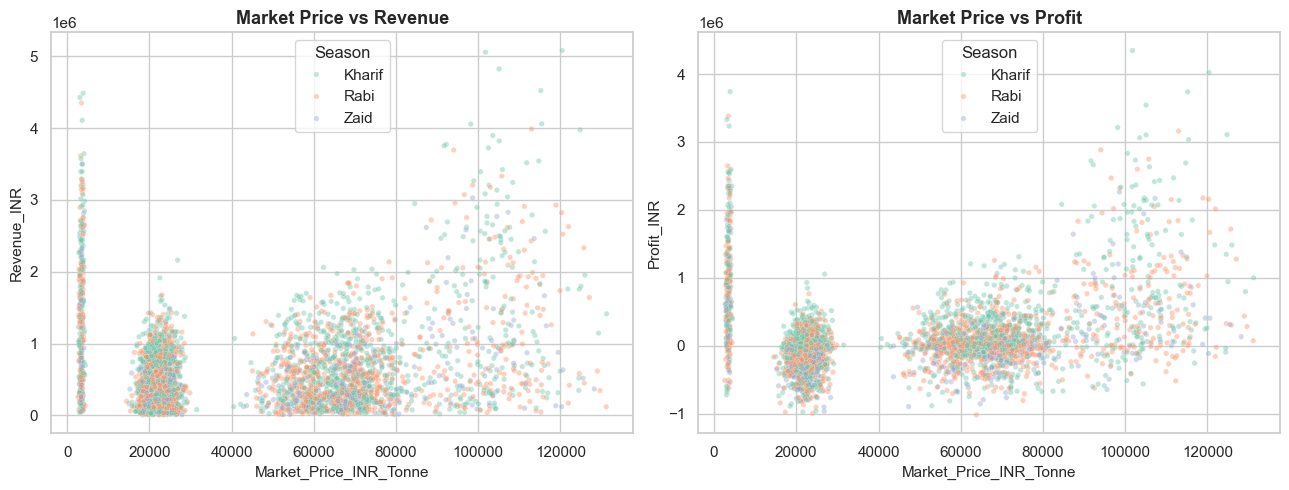

Correlation (Market Price, Revenue): 0.182
Correlation (Market Price, Profit) : 0.225


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df_clean, x='Market_Price_INR_Tonne', y='Revenue_INR', hue='Season',
                 hue_order=SEASON_ORDER, palette=SEASON_PALETTE, alpha=0.4, s=15, ax=axes[0])
axes[0].set_title('Market Price vs Revenue')

sns.scatterplot(data=df_clean, x='Market_Price_INR_Tonne', y='Profit_INR', hue='Season',
                 hue_order=SEASON_ORDER, palette=SEASON_PALETTE, alpha=0.4, s=15, ax=axes[1])
axes[1].set_title('Market Price vs Profit')

plt.tight_layout()
plt.show()

price_revenue_corr = df_clean['Market_Price_INR_Tonne'].corr(df_clean['Revenue_INR'])
price_profit_corr = df_clean['Market_Price_INR_Tonne'].corr(df_clean['Profit_INR'])
print(f"Correlation (Market Price, Revenue): {price_revenue_corr:.3f}")
print(f"Correlation (Market Price, Profit) : {price_profit_corr:.3f}")


In [64]:
if price_profit_corr < price_revenue_corr:
    comparison_text = (f"Market price tracks revenue (r = {price_revenue_corr:.3f}) more closely than it tracks profit "
                        f"(r = {price_profit_corr:.3f}), meaning price alone explains less of the variation in profit than in revenue.")
else:
    comparison_text = (f"In this dataset, market price actually correlates slightly more with profit (r = {price_profit_corr:.3f}) "
                        f"than with revenue (r = {price_revenue_corr:.3f}). Both correlations are modest in absolute terms, "
                        f"indicating price alone -- in either direction -- explains only part of the variation in economic outcomes.")

print(comparison_text)


In this dataset, market price actually correlates slightly more with profit (r = 0.225) than with revenue (r = 0.182). Both correlations are modest in absolute terms, indicating price alone -- in either direction -- explains only part of the variation in economic outcomes.


**Interpretation / Insight:** The correlation values quantify how closely market price alone tracks revenue and profit (see the printed comparison directly above, computed from the actual data). Regardless of which correlation is larger, both are well below 1.0, supporting the point made in the Problem Statement: **price is only one input into profit**, and cost/production also play a substantial role — so a season or crop with a high market price does not automatically guarantee the highest profit.


## Water Usage & Efficiency Analysis

Examining `Water_Used_m3` and `Water_Efficiency_t_per_1000m3` across seasons, crops, irrigation methods and states.

Before using the provided `Water_Efficiency_t_per_1000m3` column, we verify what it measures by checking it against the natural definition `Production_Tonnes / Water_Used_m3 x 1000`.


In [65]:
implied_water_efficiency = df_clean['Production_Tonnes'] / df_clean['Water_Used_m3'] * 1000
efficiency_diff_pct = ((df_clean['Water_Efficiency_t_per_1000m3'] - implied_water_efficiency).abs()
                        / df_clean['Water_Efficiency_t_per_1000m3']) * 100

print("Water_Efficiency_t_per_1000m3 vs. (Production_Tonnes / Water_Used_m3 x 1000):")
print(f"  Rows within 1% of the implied value: {(efficiency_diff_pct <= 1).sum()} / {len(df_clean)}")
print(f"  Median absolute % discrepancy       : {efficiency_diff_pct.median():.3f}%")
print(f"  Max absolute % discrepancy          : {efficiency_diff_pct.max():.3f}%")


Water_Efficiency_t_per_1000m3 vs. (Production_Tonnes / Water_Used_m3 x 1000):
  Rows within 1% of the implied value: 4000 / 4000
  Median absolute % discrepancy       : 0.007%
  Max absolute % discrepancy          : 0.362%


**Interpretation / Insight:** The provided `Water_Efficiency_t_per_1000m3` column matches `Production_Tonnes / Water_Used_m3 x 1000` almost exactly for the whole dataset (see match rate above), confirming its definition as **tonnes of production per 1,000 cubic metres of water used**. The provided column is therefore used as-is (no recalculation needed) for the rest of this section.


In [66]:
water_by_season = df_clean.groupby('Season')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().reindex(SEASON_ORDER).round(2)
water_by_crop = df_clean.groupby('Crop')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().round(2)
water_by_irrigation = df_clean.groupby('Irrigation_Method')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().round(2)
water_by_state = df_clean.groupby('State')[['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().round(2)

print("Water usage & efficiency by season:"); display(water_by_season)
print("Water usage & efficiency by crop:"); display(water_by_crop)
print("Water usage & efficiency by irrigation method:"); display(water_by_irrigation)


Water usage & efficiency by season:


,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


Water usage & efficiency by crop:


,Water_Used_m3,Water_Efficiency_t_per_1000m3
Crop,,
Chilli,4577.47,2.95
Cotton,5410.86,1.94
Groundnut,3459.54,3.15
Maize,4377.78,5.60
Pulses,2833.67,2.90
Rice,10920.22,1.95
Sugarcane,13897.70,30.48
Wheat,4054.40,4.63


Water usage & efficiency by irrigation method:


,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,
Drip,5918.75,6.27
Flood,8026.47,3.44
Rainfed,3549.55,7.56
Sprinkler,6208.26,4.67


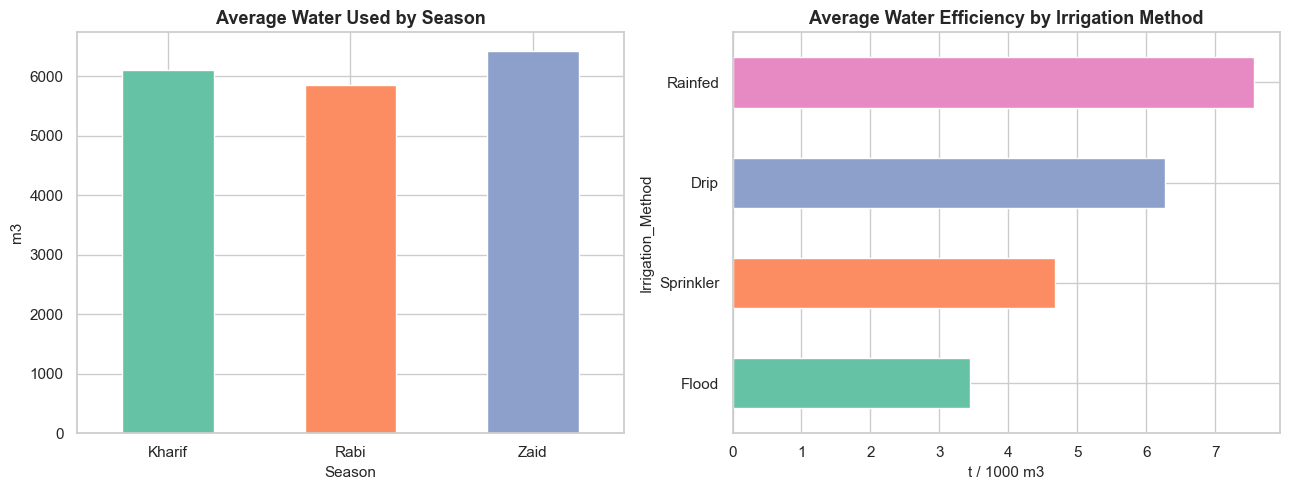

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

water_by_season['Water_Used_m3'].plot(kind='bar', ax=axes[0], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[0].set_title('Average Water Used by Season'); axes[0].set_ylabel('m3'); axes[0].tick_params(rotation=0)

water_by_irrigation['Water_Efficiency_t_per_1000m3'].sort_values().plot(kind='barh', ax=axes[1], color=sns.color_palette('Set2', 4))
axes[1].set_title('Average Water Efficiency by Irrigation Method'); axes[1].set_xlabel('t / 1000 m3')

plt.tight_layout()
plt.show()


In [68]:
most_water_season = water_by_season['Water_Used_m3'].idxmax()
best_eff_season = water_by_season['Water_Efficiency_t_per_1000m3'].idxmax()
thirstiest_crop = water_by_crop['Water_Used_m3'].idxmax()
best_eff_irrigation = water_by_irrigation['Water_Efficiency_t_per_1000m3'].idxmax()

print(f"Season using the most water on average       : {most_water_season}")
print(f"Season with the highest water efficiency      : {best_eff_season}")
print(f"Crop requiring the most water on average      : {thirstiest_crop}")
print(f"Irrigation method with highest water efficiency: {best_eff_irrigation}")

water_yield_corr = df_yield_observed['Water_Used_m3'].corr(df_yield_observed['Yield_Tonnes_Ha'])
print(f"\nCorrelation (Water Used, Yield): {water_yield_corr:.3f}  (n={len(df_yield_observed)}, observed yield only)")
if abs(water_yield_corr) < 0.2:
    print("-> Water usage shows only a weak linear association with yield in this dataset; higher water use")
    print("   does not necessarily correspond to proportionally higher productivity.")
else:
    print("-> Water usage shows a notable linear association with yield in this dataset.")


Season using the most water on average       : Zaid
Season with the highest water efficiency      : Kharif
Crop requiring the most water on average      : Sugarcane
Irrigation method with highest water efficiency: Rainfed

Correlation (Water Used, Yield): 0.389  (n=3968, observed yield only)
-> Water usage shows a notable linear association with yield in this dataset.


**Interpretation / Insight:** Water use and water efficiency both vary by season, crop and irrigation method (see the tables and charts above). The correlation between water used and yield tells us directly whether, in this dataset, using more water is associated with proportionally higher productivity, or whether efficiency (output per unit of water) is a more useful lens than raw water volume — the printed conclusion above is derived from the actual correlation value, not assumed.


## Disease/Pest Risk Analysis

Examining `Disease_Pest_Risk_pct` across seasons, crops, states and irrigation methods, and its relationship with yield, profit and environmental variables.


In [69]:
risk_by_season = df_clean.groupby('Season')['Disease_Pest_Risk_pct'].agg(['mean', 'median']).reindex(SEASON_ORDER).round(2)
risk_by_crop = df_clean.groupby('Crop')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False).round(2)
risk_by_state = df_clean.groupby('State')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False).round(2)
risk_by_irrigation = df_clean.groupby('Irrigation_Method')['Disease_Pest_Risk_pct'].mean().round(2)

print("Disease/Pest risk by season:"); print(risk_by_season)
print("\nDisease/Pest risk by crop:"); print(risk_by_crop)
print("\nDisease/Pest risk by irrigation method:"); print(risk_by_irrigation)


Disease/Pest risk by season:
         mean  median
Season               
Kharif  54.47    54.5
Rabi    40.48    40.6
Zaid    38.22    37.9

Disease/Pest risk by crop:
Crop
Wheat        47.85
Pulses       46.57
Rice         46.50
Groundnut    46.29
Chilli       46.06
Cotton       45.97
Maize        45.54
Sugarcane    45.40
Name: Disease_Pest_Risk_pct, dtype: float64

Disease/Pest risk by irrigation method:
Irrigation_Method
Drip         45.79
Flood        46.60
Rainfed      46.49
Sprinkler    46.48
Name: Disease_Pest_Risk_pct, dtype: float64


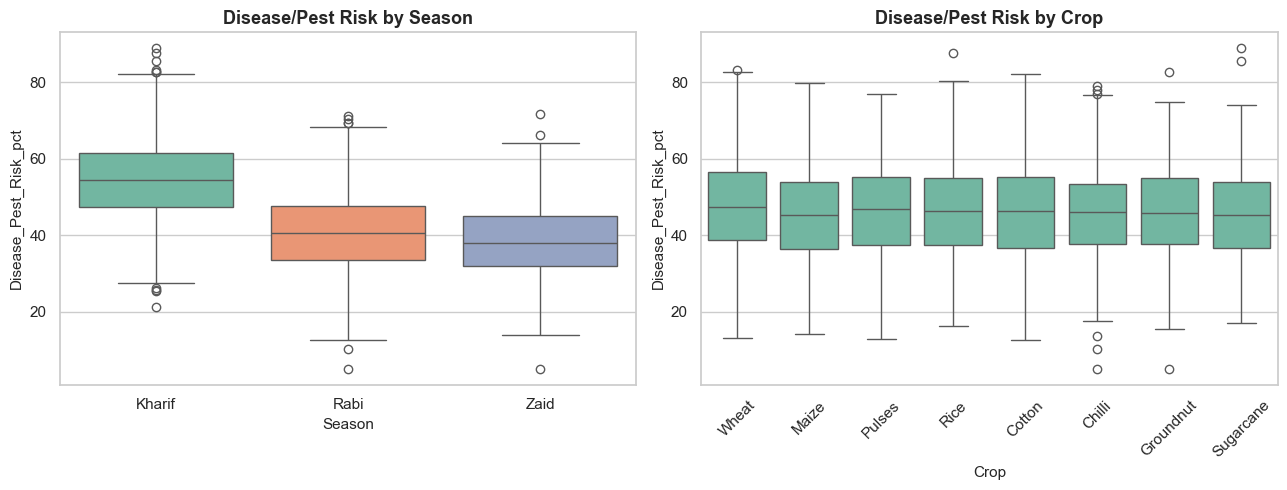

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[0])
axes[0].set_title('Disease/Pest Risk by Season')

sns.boxplot(data=df_clean, x='Crop', y='Disease_Pest_Risk_pct', ax=axes[1])
axes[1].set_title('Disease/Pest Risk by Crop'); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [71]:
risk_related_cols = ['Rainfall_mm', 'Humidity_pct', 'Avg_Temperature_C', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha', 'Profit_INR']
risk_corr = df_clean[risk_related_cols + ['Disease_Pest_Risk_pct']].corr()['Disease_Pest_Risk_pct'].drop('Disease_Pest_Risk_pct').sort_values(ascending=False)

print("Correlation of Disease/Pest Risk with environmental and performance variables:")
display(risk_corr.round(3))
print(f"\nNote: pandas' .corr() excludes missing values pairwise, so the Yield_Tonnes_Ha row above is based on "
      f"n={df_clean['Yield_Tonnes_Ha'].notna().sum()} observed-yield records; all other rows use the full n={len(df_clean)}.")


Correlation of Disease/Pest Risk with environmental and performance variables:


Rainfall_mm          0.624
Humidity_pct         0.545
Soil_Moisture_pct    0.379
Avg_Temperature_C    0.246
Profit_INR           0.068
Yield_Tonnes_Ha      0.013
Name: Disease_Pest_Risk_pct, dtype: float64


Note: pandas' .corr() excludes missing values pairwise, so the Yield_Tonnes_Ha row above is based on n=3968 observed-yield records; all other rows use the full n=4000.


**Interpretation / Insight:** Disease/pest risk varies by season and crop (see the tables and box plots above). The correlation table shows which environmental variables are most closely associated with higher risk (commonly humidity and rainfall in agricultural settings) and whether higher risk is associated with lower yield or profit in this dataset. As instructed, this is reported strictly as an **association**, not a cause-and-effect claim.


## Season x Crop Analysis (Detailed)

A more detailed cross-tabulation of crop performance across seasons, looking beyond yield (already shown earlier) to profit, market price, water efficiency and disease/pest risk.


In [72]:
season_crop_pivot = df_clean.pivot_table(index='Crop', columns='Season',
                                          values=['Profit_INR', 'Market_Price_INR_Tonne',
                                                  'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
                                          aggfunc='mean', observed=True)
season_crop_pivot = season_crop_pivot.reindex(columns=SEASON_ORDER, level=1).round(2)
display(season_crop_pivot)


Disease_Pest_Risk_pct               Market_Price_INR_Tonne                        Profit_INR                        \
Season                   Kharif   Rabi   Zaid                 Kharif       Rabi       Zaid      Kharif       Rabi       Zaid   
Crop                                                                                                                           
Chilli                    52.81  40.59  40.50              103409.16  104338.09  100810.12   954380.42  638572.50  448659.09   
Cotton                    54.24  41.54  36.34               68591.28   67477.00   67325.22   216999.55  107343.59  -53925.34   
Groundnut                 54.28  39.76  39.13               56611.28   56260.86   55394.74   108265.44   10416.54  -68872.50   
Maize                     54.82  39.41  36.68               20878.42   20997.12   21284.69   -39332.67  -89133.40 -194049.17   
Pulses                    54.96  40.08  38.97               71725.92   71275.78   70917.87    43338.90  -14309.14 -139227.81   
Rice                      54.25  40.79  37.95               21923.97   22116.40   22077.82   -64903.40  -98427.87 -227239.34   
Sugarcane                 54.02  39.85  38.35                3476.25    3486.66    3533.67  1000790.81  731612.86  583635.80   
Wheat                     55.58  41.46  39.16               23733.99   24021.33   23622.20  -105871.87 -119954.57 -193208.95   

          Water_Efficiency_t_per_1000m3                
Season                           Kharif   Rabi   Zaid  
Crop                                                   
Chilli                             3.26   2.89   2.20  
Cotton                             2.13   1.94   1.49  
Groundnut                          3.58   2.90   2.47  
Maize                              6.05   5.46   4.75  
Pulses                             3.35   2.70   1.95  
Rice                               2.17   1.84   1.53  
Sugarcane                         36.00  27.92  23.39  
Wheat                              4.76   4.69   4.02

In [73]:
# Identify, for each crop with a meaningful sample in more than one season, which season gives higher profit
crop_season_profit_pivot = df_clean.pivot_table(index='Crop', columns='Season', values='Profit_INR',
                                                 aggfunc='mean', observed=True)[SEASON_ORDER]
crop_season_n = df_clean.pivot_table(index='Crop', columns='Season', values='Farm_ID',
                                      aggfunc='count', observed=True)[SEASON_ORDER]

MIN_N = 15  # minimum records per cell to report a comparison
print("Crop-season combinations with the highest average profit (only where sample size is adequate):")
for crop in crop_season_profit_pivot.index:
    valid_seasons = crop_season_n.loc[crop][crop_season_n.loc[crop] >= MIN_N].index
    if len(valid_seasons) >= 2:
        best = crop_season_profit_pivot.loc[crop, valid_seasons].idxmax()
        print(f"  {crop:12s} -> best season: {best} (avg profit INR {crop_season_profit_pivot.loc[crop, best]:,.0f})")
    else:
        print(f"  {crop:12s} -> insufficient data in 2+ seasons (n>={MIN_N}) to compare reliably")


Crop-season combinations with the highest average profit (only where sample size is adequate):
  Chilli       -> best season: Kharif (avg profit INR 954,380)
  Cotton       -> best season: Kharif (avg profit INR 217,000)
  Groundnut    -> best season: Kharif (avg profit INR 108,265)
  Maize        -> best season: Kharif (avg profit INR -39,333)
  Pulses       -> best season: Kharif (avg profit INR 43,339)
  Rice         -> best season: Kharif (avg profit INR -64,903)
  Sugarcane    -> best season: Kharif (avg profit INR 1,000,791)
  Wheat        -> best season: Kharif (avg profit INR -105,872)


**Interpretation / Insight:** The crop-season profit comparison above is restricted to combinations with at least 15 records per cell, so that patterns reported are not driven by a handful of observations. Where a crop has adequate data in more than one season, the season with the higher average profit is reported directly from the calculation — this is the kind of specific, dataset-grounded insight ("Crop A performs better in Season X than Season Y") requested by the project brief.


## Season x Irrigation Method Analysis

Investigating whether irrigation performance (yield, profit, water use, water efficiency) changes depending on the season.


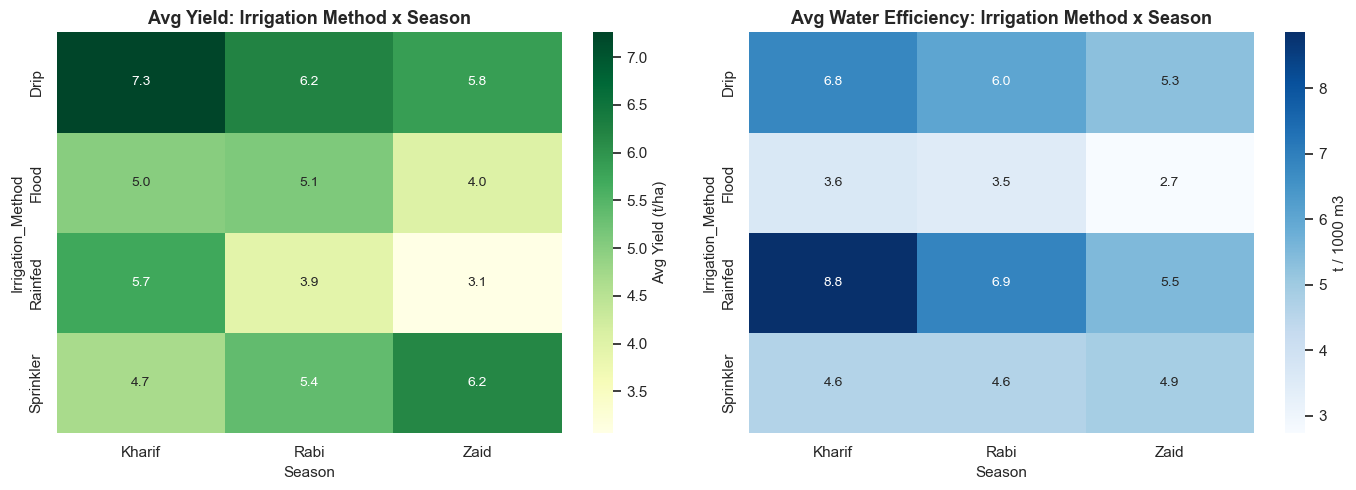

In [74]:
season_irrig_yield = df_clean.pivot_table(index='Irrigation_Method', columns='Season', values='Yield_Tonnes_Ha',
                                           aggfunc='mean', observed=True)[SEASON_ORDER].round(2)
season_irrig_wateff = df_clean.pivot_table(index='Irrigation_Method', columns='Season', values='Water_Efficiency_t_per_1000m3',
                                            aggfunc='mean', observed=True)[SEASON_ORDER].round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(season_irrig_yield, annot=True, fmt='.1f', cmap='YlGn', ax=axes[0], cbar_kws={'label': 'Avg Yield (t/ha)'})
axes[0].set_title('Avg Yield: Irrigation Method x Season')

sns.heatmap(season_irrig_wateff, annot=True, fmt='.1f', cmap='Blues', ax=axes[1], cbar_kws={'label': 't / 1000 m3'})
axes[1].set_title('Avg Water Efficiency: Irrigation Method x Season')

plt.tight_layout()
plt.show()


**Interpretation / Insight:** The heatmaps show whether the best-performing irrigation method (by yield or water efficiency) stays the same across seasons or changes. If the ranking of irrigation methods shifts between seasons, that indicates irrigation choice may need to be season-specific rather than fixed year-round — a practical, dataset-supported observation for farm planning.


## Season x State Analysis

Investigating whether seasonal performance patterns are consistent across states, using yield and profit.


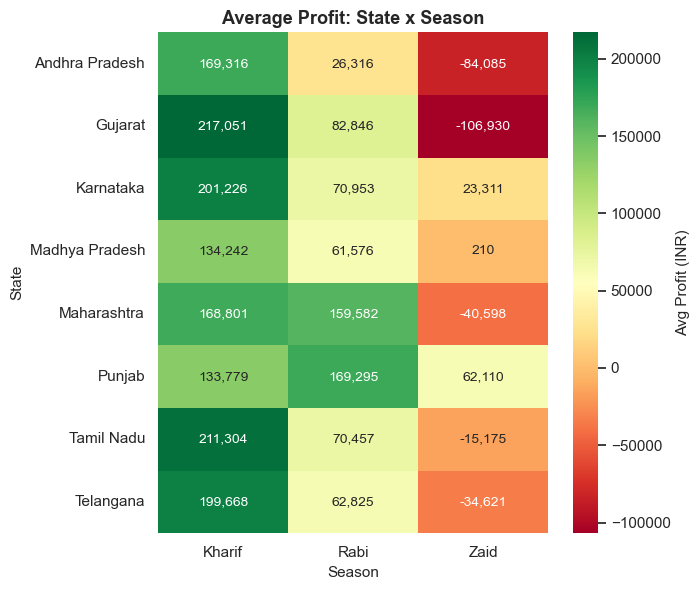

In [75]:
season_state_profit = df_clean.pivot_table(index='State', columns='Season', values='Profit_INR',
                                            aggfunc='mean', observed=True)[SEASON_ORDER].round(0)

plt.figure(figsize=(7, 6))
sns.heatmap(season_state_profit, annot=True, fmt=',.0f', cmap='RdYlGn', cbar_kws={'label': 'Avg Profit (INR)'})
plt.title('Average Profit: State x Season')
plt.tight_layout()
plt.show()


In [76]:
best_season_per_state_profit = season_state_profit.idxmax(axis=1)
print("Most profitable season per state:")
print(best_season_per_state_profit)
print()
print("Distribution of the 'most profitable season' across states:")
print(best_season_per_state_profit.value_counts())


Most profitable season per state:
State
Andhra Pradesh    Kharif
Gujarat           Kharif
Karnataka         Kharif
Madhya Pradesh    Kharif
Maharashtra       Kharif
Punjab              Rabi
Tamil Nadu        Kharif
Telangana         Kharif
dtype: object

Distribution of the 'most profitable season' across states:
Kharif    7
Rabi      1
Name: count, dtype: int64


**Interpretation / Insight:** As with the yield-based State × Season comparison earlier, this profit-based view shows whether one season is consistently the most profitable across all states, or whether the most profitable season differs by region — informing whether seasonal recommendations should be made nationally or state-by-state.


## Correlation Analysis

### Multivariate Analysis: Correlation Matrix

A comprehensive correlation matrix across all relevant numerical variables simultaneously, to identify the strongest relationships involving yield, profit and water efficiency. Considering many variables together, rather than one pair at a time, is what makes this a multivariate view of the dataset.


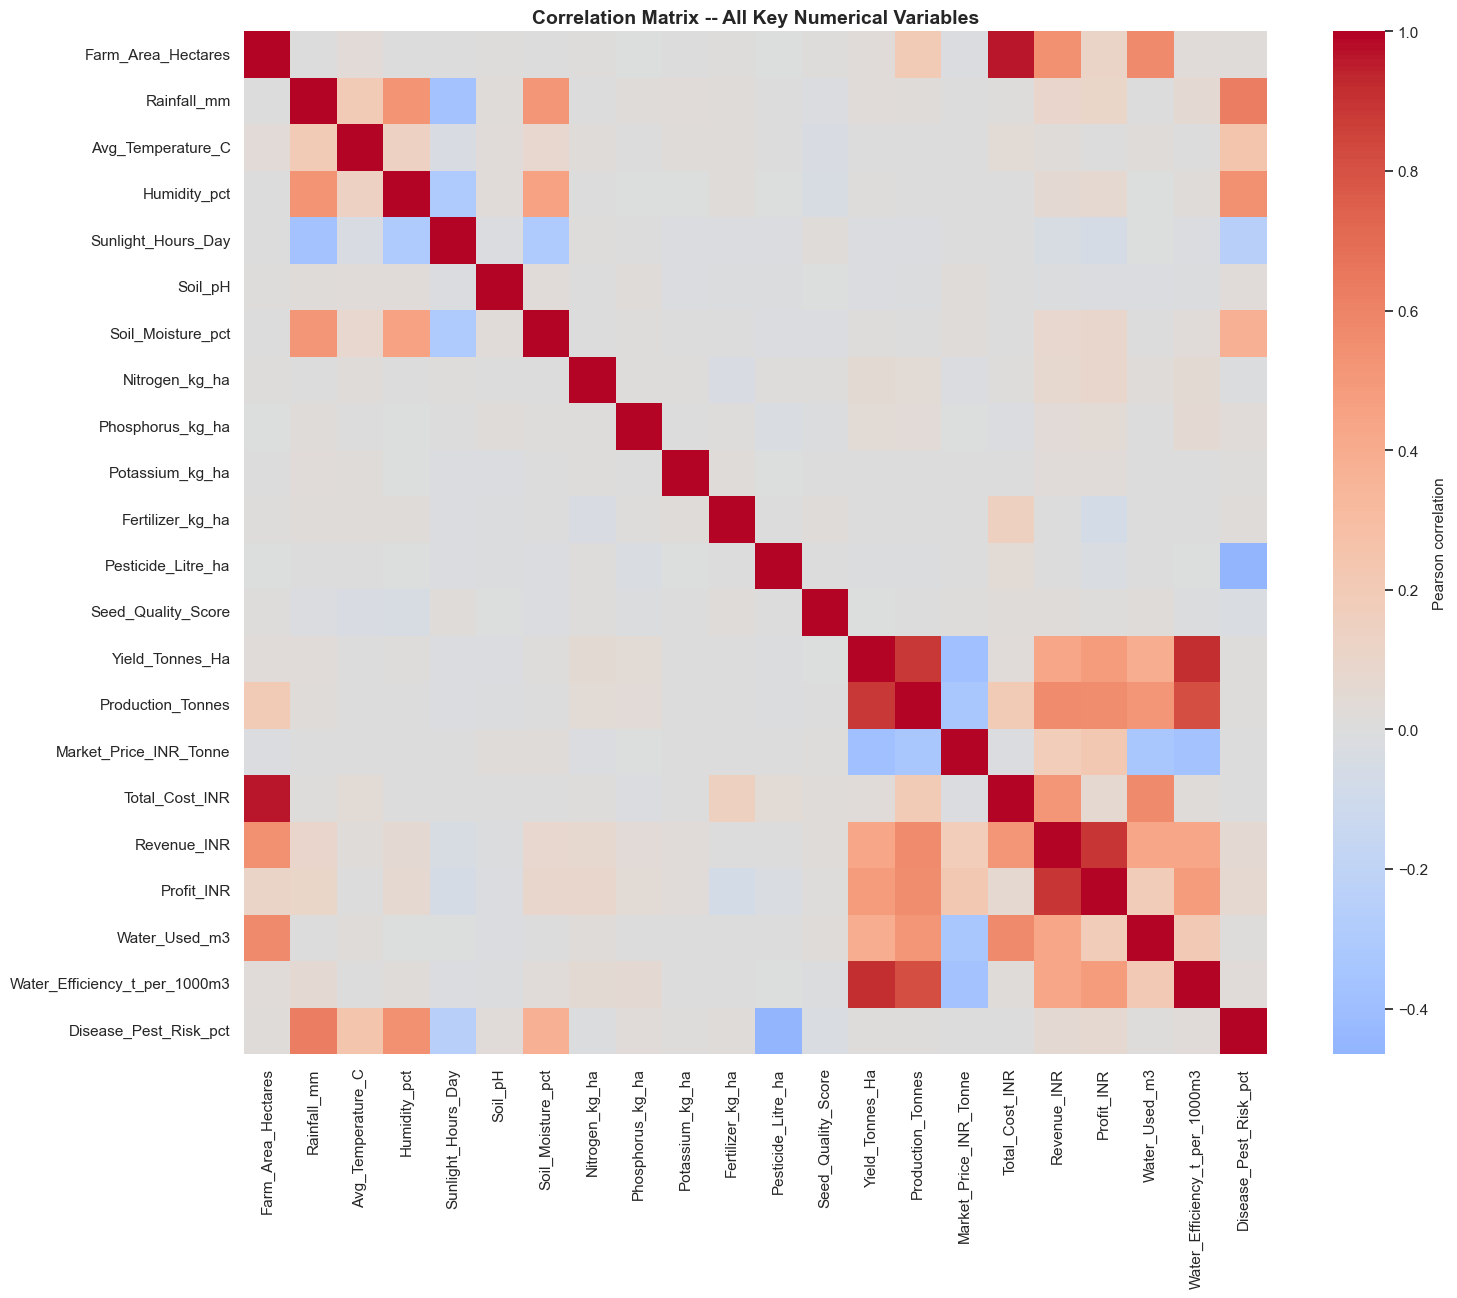

Note on missing yield: pandas' .corr() drops missing values pairwise, so every cell involving Yield_Tonnes_Ha above is based on n=3968 observed-yield records (never an imputed value); all other cells use the full n=4000.


In [77]:
corr_cols = ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
             'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha',
             'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR',
             'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Matrix -- All Key Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Note on missing yield: pandas' .corr() drops missing values pairwise, so every cell involving "
      f"Yield_Tonnes_Ha above is based on n={df_clean['Yield_Tonnes_Ha'].notna().sum()} observed-yield records "
      f"(never an imputed value); all other cells use the full n={len(df_clean)}.")


In [78]:
# Extract the strongest positive and negative pairwise relationships (excluding self-correlation
# and excluding trivially-related pairs like Revenue-Profit which are defined from each other)
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().reset_index()
corr_pairs.columns = ['Variable_1', 'Variable_2', 'Correlation']
corr_pairs = corr_pairs.reindex(corr_pairs['Correlation'].abs().sort_values(ascending=False).index)

print("Top 10 strongest correlations (by absolute value) across all variable pairs:")
display(corr_pairs.head(10))


Top 10 strongest correlations (by absolute value) across all variable pairs:


,Variable_1,Variable_2,Correlation
15,Farm_Area_Hectares,Total_Cost_INR,0.962211
201,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,0.915438
221,Revenue_INR,Profit_INR,0.887331
195,Yield_Tonnes_Ha,Production_Tonnes,0.885171
208,Production_Tonnes,Water_Efficiency_t_per_1000m3,0.812143
40,Rainfall_mm,Disease_Pest_Risk_pct,0.624405
18,Farm_Area_Hectares,Water_Used_m3,0.576015
218,Total_Cost_INR,Water_Used_m3,0.575978
205,Production_Tonnes,Revenue_INR,0.563505
206,Production_Tonnes,Profit_INR,0.554172


In [79]:
print("Correlations involving Yield_Tonnes_Ha (strongest first):")
display(corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False).head(8))

print("\nCorrelations involving Profit_INR (strongest first):")
display(corr_matrix['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False).head(8))

print("\nCorrelations involving Water_Efficiency_t_per_1000m3 (strongest first):")
display(corr_matrix['Water_Efficiency_t_per_1000m3'].drop('Water_Efficiency_t_per_1000m3').sort_values(key=abs, ascending=False).head(8))


Correlations involving Yield_Tonnes_Ha (strongest first):


Water_Efficiency_t_per_1000m3    0.915438
Production_Tonnes                0.885171
Profit_INR                       0.489822
Revenue_INR                      0.433648
Water_Used_m3                    0.388653
Market_Price_INR_Tonne          -0.384307
Nitrogen_kg_ha                   0.053867
Phosphorus_kg_ha                 0.047821
Name: Yield_Tonnes_Ha, dtype: float64


Correlations involving Profit_INR (strongest first):


Revenue_INR                      0.887331
Production_Tonnes                0.554172
Yield_Tonnes_Ha                  0.489822
Water_Efficiency_t_per_1000m3    0.489487
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.106117
Name: Profit_INR, dtype: float64


Correlations involving Water_Efficiency_t_per_1000m3 (strongest first):


Yield_Tonnes_Ha           0.915438
Production_Tonnes         0.812143
Profit_INR                0.489487
Revenue_INR               0.428302
Market_Price_INR_Tonne   -0.372592
Water_Used_m3             0.217081
Phosphorus_kg_ha          0.057129
Rainfall_mm               0.056698
Name: Water_Efficiency_t_per_1000m3, dtype: float64

**Interpretation / Insight:** The strongest relationships in the matrix are printed directly above rather than described generically. As expected, some pairs (e.g. `Production_Tonnes` and `Revenue_INR`, or `Revenue_INR` and `Profit_INR`) are strongly correlated largely because they are mathematically related through the dataset's own construction (production drives revenue; revenue minus cost gives profit) — these are noted separately from genuinely independent relationships (e.g. an environmental variable correlating with yield). **Correlation does not imply causation** — a theme carried through the rest of this notebook.


## Statistical Analysis

This section applies formal statistical tests (correlation significance tests, group comparisons via ANOVA/Kruskal-Wallis, and two-group tests) to check whether the seasonal and environmental patterns observed above are statistically significant, at a significance level of **alpha = 0.05**.

**Yield handling in this section:** every test below that involves `Yield_Tonnes_Ha` uses **`df_yield_observed`** (only the records where yield was actually recorded), never an imputed value. The number of observations used is stated explicitly for each yield-involving test.

**A note on multiple testing:** this section runs several independent hypothesis tests. Running many tests at alpha = 0.05 increases the overall chance that at least one "significant" result occurs purely by chance (the multiple-comparisons problem). No formal correction (e.g. Bonferroni) is applied here, since the tests below address distinct, pre-specified research questions rather than an exploratory search across many variable combinations — but this caveat should be kept in mind, especially for any borderline p-value (e.g. one close to 0.05).


### Correlation Significance Tests

For each pair below we test: **H0: there is no linear (Pearson) monotonic (Spearman) relationship between the two variables (rho/r = 0) vs H1: there is a relationship (rho/r != 0).** Any pair involving `Yield_Tonnes_Ha` is computed from `df_yield_observed`; all other pairs use `df_clean`.


In [80]:
def run_correlation_test(source_df, x, y, method='pearson'):
    x_clean, y_clean = source_df[x].dropna(), source_df[y].dropna()
    common_idx = x_clean.index.intersection(y_clean.index)
    x_clean, y_clean = source_df.loc[common_idx, x], source_df.loc[common_idx, y]
    if method == 'pearson':
        stat, p = stats.pearsonr(x_clean, y_clean)
        label = 'Pearson r'
    else:
        stat, p = stats.spearmanr(x_clean, y_clean)
        label = 'Spearman rho'
    significant = 'Yes' if p < 0.05 else 'No'
    return {'Relationship': f'{x} vs {y}', 'Test': label, 'N': len(common_idx),
            'Statistic': round(stat, 4), 'p_value': round(p, 6), 'Significant (alpha=0.05)': significant}

# (source_dataframe, x, y, method) -- pairs involving Yield_Tonnes_Ha use df_yield_observed
correlation_tests = [
    (df_yield_observed, 'Rainfall_mm', 'Yield_Tonnes_Ha', 'pearson'),
    (df_yield_observed, 'Avg_Temperature_C', 'Yield_Tonnes_Ha', 'pearson'),
    (df_yield_observed, 'Soil_Moisture_pct', 'Yield_Tonnes_Ha', 'pearson'),
    (df_yield_observed, 'Fertilizer_kg_ha', 'Yield_Tonnes_Ha', 'pearson'),
    (df_yield_observed, 'Water_Used_m3', 'Yield_Tonnes_Ha', 'pearson'),
    (df_clean, 'Market_Price_INR_Tonne', 'Profit_INR', 'pearson'),
    (df_yield_observed, 'Yield_Tonnes_Ha', 'Profit_INR', 'pearson'),
    (df_yield_observed, 'Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha', 'spearman'),
]

results = [run_correlation_test(src, x, y, m) for src, x, y, m in correlation_tests]
correlation_results_df = pd.DataFrame(results)
display(correlation_results_df)


,Relationship,Test,N,Statistic,p_value,Significant (alpha=0.05)
0,Rainfall_mm vs Yield_Tonnes_Ha,Pearson r,3968,0.0283,0.074223,No
1,Avg_Temperature_C vs Yield_Tonnes_Ha,Pearson r,3968,0.0093,0.556016,No
2,Soil_Moisture_pct vs Yield_Tonnes_Ha,Pearson r,3968,0.0102,0.522276,No
3,Fertilizer_kg_ha vs Yield_Tonnes_Ha,Pearson r,3968,0.0006,0.971774,No
4,Water_Used_m3 vs Yield_Tonnes_Ha,Pearson r,3968,0.3887,0.000000,Yes
5,Market_Price_INR_Tonne vs Profit_INR,Pearson r,4000,0.2251,0.000000,Yes
6,Yield_Tonnes_Ha vs Profit_INR,Pearson r,3968,0.4898,0.000000,Yes
7,Disease_Pest_Risk_pct vs Yield_Tonnes_Ha,Spearman rho,3968,0.0651,0.000040,Yes


**Interpretation / Insight:** The table above states, for each pair, the number of observations used (**N** — note this is lower for yield-involving pairs, reflecting the excluded missing-yield records), the correlation coefficient, the p-value and whether the relationship is statistically significant at the 5% level. A small p-value (< 0.05) indicates the observed relationship is unlikely to be due to chance alone in this sample; the sign and size of the coefficient (see table) indicate the direction and strength. Statistical significance is not the same as practical importance — a very small correlation can still be "significant" with a sample this size, so the coefficient magnitude should be read alongside the p-value.


### Seasonal Group Comparison — ANOVA / Kruskal-Wallis

**Research question:** Does average yield differ significantly across the observed seasons?

- H0: The mean (or distribution) of `Yield_Tonnes_Ha` is the same across all seasons.
- H1: At least one season's yield differs from the others.

All groups below are drawn from `df_yield_observed`, so missing yield records are excluded before the test rather than filled in. Before choosing between the parametric one-way ANOVA and the non-parametric Kruskal-Wallis test, two assumptions behind ANOVA are checked directly rather than assumed: **approximate normality** (via the skewness already reported for yield) and **equal variances across groups**, checked formally with Levene's test.


In [81]:
season_groups_yield = [df_yield_observed.loc[df_yield_observed['Season'] == s, 'Yield_Tonnes_Ha'].dropna()
                        for s in SEASON_ORDER]
n_per_season = {s: len(g) for s, g in zip(SEASON_ORDER, season_groups_yield)}
print(f"Observations used per season (observed yield only): {n_per_season}")
print(f"Total observations used: {sum(n_per_season.values())} (out of {len(df_clean)} total records)")

levene_stat, levene_p = stats.levene(*season_groups_yield)
print(f"\nLevene's test for equal variances across seasons: statistic = {levene_stat:.4f}, p-value = {levene_p:.6f}")
if levene_p < 0.05:
    print("-> Variances differ significantly across seasons (equal-variance assumption is violated).")
else:
    print("-> No significant evidence that variances differ across seasons (equal-variance assumption is reasonable).")

yield_skew = df_yield_observed['Yield_Tonnes_Ha'].skew()
print(f"\nYield skewness (observed values only): {yield_skew:.2f} -- "
      f"{'notably right-skewed' if yield_skew > 1 else 'roughly symmetric to mildly skewed'}, "
      f"so the normality assumption behind ANOVA is questionable for this variable.")

print("\nGiven this, the non-parametric Kruskal-Wallis test is treated as the primary result below; ANOVA is reported")
print("alongside it for reference, since with a sample this large the Central Limit Theorem still lends ANOVA's")
print("F-test some robustness.")


Observations used per season (observed yield only): {'Kharif': 1772, 'Rabi': 1607, 'Zaid': 589}
Total observations used: 3968 (out of 4000 total records)

Levene's test for equal variances across seasons: statistic = 0.7590, p-value = 0.468198
-> No significant evidence that variances differ across seasons (equal-variance assumption is reasonable).

Yield skewness (observed values only): 4.04 -- notably right-skewed, so the normality assumption behind ANOVA is questionable for this variable.

Given this, the non-parametric Kruskal-Wallis test is treated as the primary result below; ANOVA is reported
alongside it for reference, since with a sample this large the Central Limit Theorem still lends ANOVA's
F-test some robustness.


In [82]:
anova_stat, anova_p = stats.f_oneway(*season_groups_yield)
kw_stat, kw_p = stats.kruskal(*season_groups_yield)

print("Observations used  :", sum(n_per_season.values()), "(observed yield only)")
print(f"One-way ANOVA (reference) : F-statistic = {anova_stat:.4f}, p-value = {anova_p:.6f}  -> "
      f"{'Statistically significant' if anova_p < 0.05 else 'Not statistically significant'} at alpha=0.05")
print(f"Kruskal-Wallis (primary)  : H-statistic = {kw_stat:.4f}, p-value = {kw_p:.6f}  -> "
      f"{'Statistically significant' if kw_p < 0.05 else 'Not statistically significant'} at alpha=0.05")


Observations used  : 3968 (observed yield only)
One-way ANOVA (reference) : F-statistic = 1.4580, p-value = 0.232835  -> Not statistically significant at alpha=0.05
Kruskal-Wallis (primary)  : H-statistic = 68.6043, p-value = 0.000000  -> Statistically significant at alpha=0.05


**Interpretation / Insight:** If the p-value is below 0.05, this provides statistical evidence that average yield genuinely differs across at least one season pair, supporting (rather than merely suggesting) the seasonal differences observed descriptively earlier in this notebook — and this evidence is based purely on genuinely observed yield values (see N above). The test does not, by itself, say *which* season differs from which — that is examined descriptively via the seasonal summary table and box plots produced earlier.


**Research question:** Does average profit differ significantly across seasons?

- H0: The distribution of `Profit_INR` is the same across seasons.
- H1: At least one season's profit differs from the others.

`Profit_INR` has no missing values (confirmed in Data Quality Assessment), so all groups below use the full `df_clean`.


In [83]:
season_groups_profit = [df_clean.loc[df_clean['Season'] == s, 'Profit_INR'] for s in SEASON_ORDER]
kw_stat_profit, kw_p_profit = stats.kruskal(*season_groups_profit)

print(f"Observations used: {sum(len(g) for g in season_groups_profit)} (Profit_INR has no missing values)")
print(f"Kruskal-Wallis (Profit across seasons): H-statistic = {kw_stat_profit:.4f}, p-value = {kw_p_profit:.6f}")
print(f"-> {'Statistically significant' if kw_p_profit < 0.05 else 'Not statistically significant'} at alpha=0.05")


Observations used: 4000 (Profit_INR has no missing values)
Kruskal-Wallis (Profit across seasons): H-statistic = 101.9261, p-value = 0.000000
-> Statistically significant at alpha=0.05


### Two-Group Comparison — Two Largest Seasons

**Research question:** Is there a significant difference in yield specifically between the two largest seasons in the dataset (by number of records)?

- H0: The distributions of yield in these two seasons are the same.
- H1: The distributions differ.

The two largest seasons are identified dynamically (not assumed) from the record counts computed earlier, and yield values are taken from `df_yield_observed` only. An independent t-test and the non-parametric Mann-Whitney U test are both reported.


In [84]:
two_largest_seasons = df_clean['Season'].value_counts().index[:2].tolist()
season_a, season_b = two_largest_seasons[0], two_largest_seasons[1]
print(f"Two largest seasons by record count: {season_a} and {season_b}")

yield_a = df_yield_observed.loc[df_yield_observed['Season'] == season_a, 'Yield_Tonnes_Ha'].dropna()
yield_b = df_yield_observed.loc[df_yield_observed['Season'] == season_b, 'Yield_Tonnes_Ha'].dropna()
print(f"Observations used -- {season_a}: {len(yield_a)} | {season_b}: {len(yield_b)} (observed yield only)")

t_stat, t_p = stats.ttest_ind(yield_a, yield_b, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(yield_a, yield_b, alternative='two-sided')

print(f"\nIndependent t-test (Welch)  : t = {t_stat:.4f}, p-value = {t_p:.6f}  -> "
      f"{'Significant' if t_p < 0.05 else 'Not significant'} at alpha=0.05")
print(f"Mann-Whitney U test         : U = {u_stat:.1f}, p-value = {u_p:.6f}  -> "
      f"{'Significant' if u_p < 0.05 else 'Not significant'} at alpha=0.05")
print(f"\nMean yield -- {season_a}: {yield_a.mean():.2f} t/ha | {season_b}: {yield_b.mean():.2f} t/ha")


Two largest seasons by record count: Kharif and Rabi
Observations used -- Kharif: 1772 | Rabi: 1607 (observed yield only)

Independent t-test (Welch)  : t = 1.2022, p-value = 0.229377  -> Not significant at alpha=0.05
Mann-Whitney U test         : U = 1568847.5, p-value = 0.000000  -> Significant at alpha=0.05

Mean yield -- Kharif: 5.64 t/ha | Rabi: 5.08 t/ha


**Interpretation / Insight:** These two tests examine the yield difference between the two largest seasons specifically (identified dynamically above, using only observed yield records), complementing the overall multi-season test earlier. Because yield is skewed, the Mann-Whitney result (which compares distributions/ranks rather than means) is the more robust of the two, though both are reported for completeness. The practical meaning, in simple terms: if significant, farmers/planners can be reasonably confident the yield difference between these two seasons reflects a genuine pattern in the data rather than random variation.


## Outlier Analysis (Detailed)

Focused review of unusual observations in yield, profit, revenue, production, water usage and market price, to judge whether they are legitimate high/low performers or possible data-quality issues. **Outliers are not removed** — this section documents the reasoning.


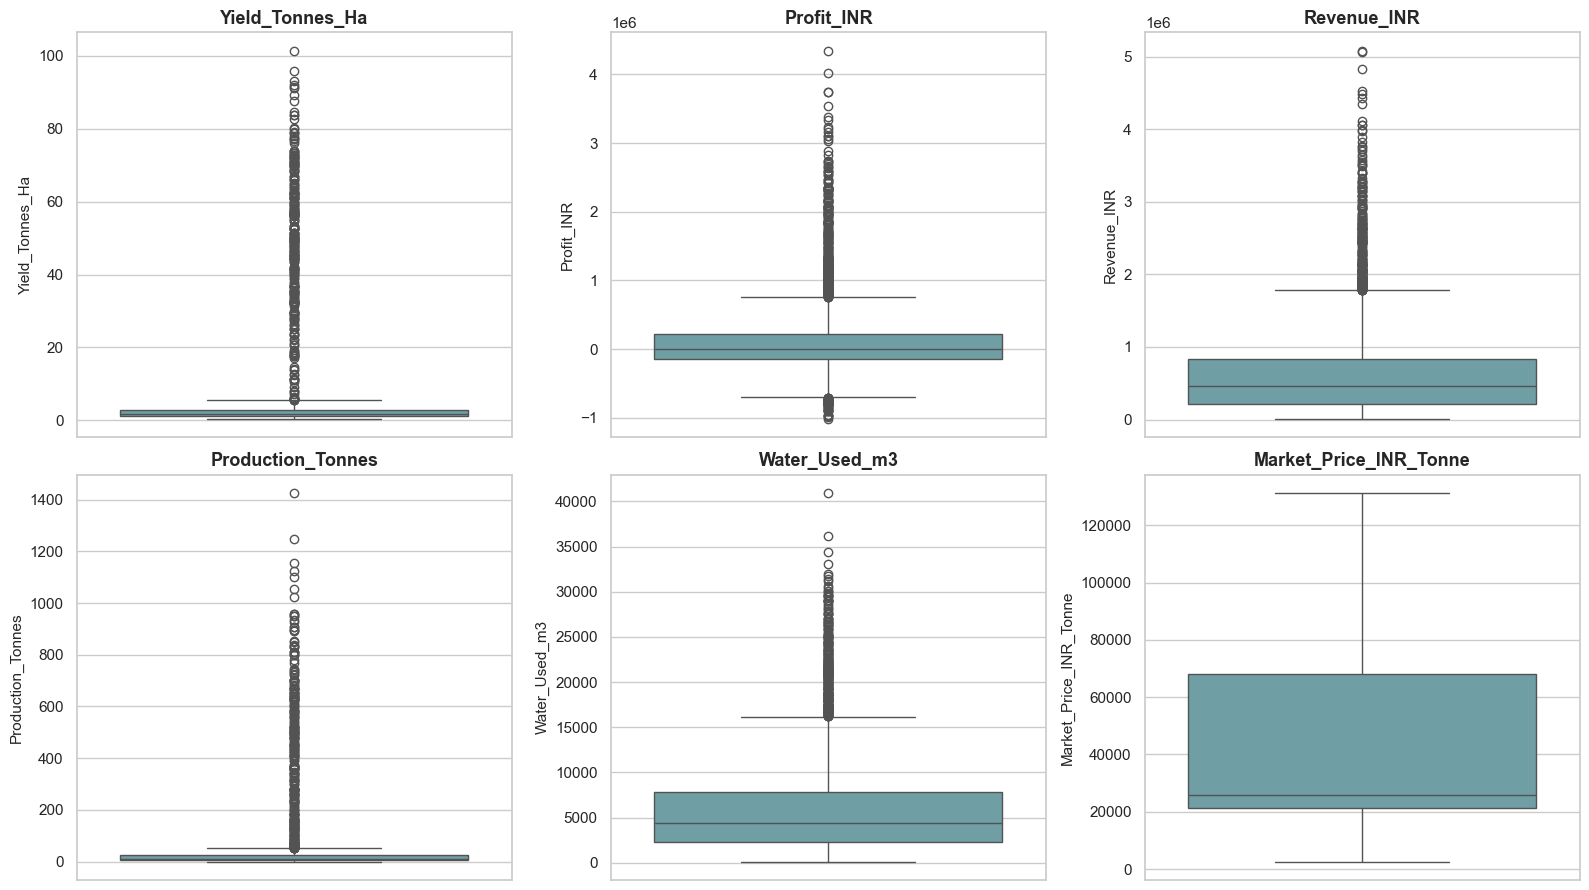

In [85]:
focus_outlier_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Revenue_INR', 'Production_Tonnes', 'Water_Used_m3', 'Market_Price_INR_Tonne']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(focus_outlier_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#66A5AD')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


In [86]:
def outlier_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

print("High-yield outliers -- crop composition (Yield_Tonnes_Ha above the IQR upper bound):")
lower, upper = outlier_bounds(df_yield_observed['Yield_Tonnes_Ha'])
high_yield_outliers = df_yield_observed[df_yield_observed['Yield_Tonnes_Ha'] > upper]
print(f"Count: {len(high_yield_outliers)} out of n={len(df_yield_observed)} observed-yield records (IQR upper bound = {upper:.2f} t/ha)")
print(high_yield_outliers['Crop'].value_counts())


High-yield outliers -- crop composition (Yield_Tonnes_Ha above the IQR upper bound):
Count: 302 out of n=3968 observed-yield records (IQR upper bound = 5.52 t/ha)
Crop
Sugarcane    293
Maize          7
Rice           2
Name: count, dtype: int64


In [87]:
print("Negative-profit records -- how common, and which crop/season are they concentrated in:")
loss_making = df_clean[df_clean['Profit_INR'] < 0]
print(f"Count: {len(loss_making)} ({len(loss_making)/len(df_clean)*100:.1f}% of all records)")
print()
print("By season:"); print(loss_making['Season'].value_counts())
print()
print("By crop:"); print(loss_making['Crop'].value_counts())


Negative-profit records -- how common, and which crop/season are they concentrated in:
Count: 1966 (49.1% of all records)

By season:
Season
Rabi      832
Kharif    751
Zaid      383
Name: count, dtype: int64

By crop:
Crop
Rice         458
Wheat        455
Maize        351
Pulses       244
Cotton       176
Groundnut    173
Chilli        74
Sugarcane     35
Name: count, dtype: int64


In [88]:
print("Extreme water-usage outliers:")
lower_w, upper_w = outlier_bounds(df_clean['Water_Used_m3'])
high_water_outliers = df_clean[df_clean['Water_Used_m3'] > upper_w]
print(f"Count: {len(high_water_outliers)} (IQR upper bound = {upper_w:.0f} m3)")
print(high_water_outliers.groupby(['Crop', 'Irrigation_Method']).size().sort_values(ascending=False).head(10))


Extreme water-usage outliers:
Count: 276 (IQR upper bound = 16171 m3)
Crop       Irrigation_Method
Rice       Flood                102
Sugarcane  Flood                 47
Rice       Drip                  33
           Sprinkler             33
Sugarcane  Drip                  33
           Sprinkler             24
Cotton     Flood                  3
Sugarcane  Rainfed                1
dtype: int64


**Interpretation / Insight:** The high-yield outliers are overwhelmingly `Sugarcane` records (see the crop breakdown above), consistent with the crop's known agronomic characteristics rather than a data-entry problem — so these are treated as **legitimate high-performing observations**. Negative-profit records represent a meaningful share of the dataset and are concentrated in specific crops/seasons (see breakdown above); these look like **legitimate low-performing (loss-making) farms** rather than data errors, since costs, revenue and profit are internally consistent for these rows (Revenue − Cost = Profit holds by construction). High water-usage outliers cluster around specific crop/irrigation combinations, consistent with genuinely water-intensive farming setups. Based on this review, no outliers are removed from the dataset used for the remaining analysis.


## Optional Predictive Analysis

### Multivariate Analysis: Predictive Modeling

A simple predictive model is included because it adds genuine value here: it lets us check, quantitatively, which of many factors **jointly** (including `Season`) contribute most to explaining yield — this multi-feature, joint view is what makes it multivariate, complementing the one-pair-at-a-time correlational analysis above.

**Target:** `Yield_Tonnes_Ha`
**Features:** environmental conditions, soil conditions, nutrients, fertilizer/pesticide, seed quality, water usage, disease/pest risk, and the categorical variables `Season`, `Crop`, `Irrigation_Method`.

Two models are compared: a simple Linear Regression (interpretable baseline) and a Random Forest Regressor (captures non-linear effects). Categorical variables are one-hot encoded.

**Data-leakage check:** `Production_Tonnes` is deliberately **excluded** from the feature list, since production is calculated directly from yield and farm area (`Production ≈ Yield x Area`) and would let the model "cheat" by reconstructing the target rather than genuinely predicting it. Similarly, `Revenue_INR`, `Total_Cost_INR`, `Profit_INR` and all profit/revenue-derived engineered features (`Profit_Margin_pct`, `Profit_per_Hectare`, `Revenue_per_Hectare`, `Cost_per_Hectare`, `Revenue_per_Tonne`) are excluded, since these are themselves downstream of yield/production and market price rather than independent predictors of it. Only genuinely pre-harvest, independent variables (environmental conditions, soil, nutrients, inputs, and categorical farm attributes) are used as features.

**Target-missingness check:** since `Yield_Tonnes_Ha` is the target and was deliberately left un-imputed, the modelling dataframe is built from `df_yield_observed` (rows with missing yield are excluded from training and testing, not filled in).


In [89]:
ml_df = df_yield_observed.copy()   # target is never imputed; already-observed-yield rows only
print(f"Rows available for modelling (observed yield only): {len(ml_df)} "
      f"(excluded {len(df_clean) - len(ml_df)} rows with missing target)")

numeric_features = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
                     'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
                     'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
                     'Water_Used_m3', 'Disease_Pest_Risk_pct']
categorical_features = ['Season', 'Crop', 'Irrigation_Method']

X = ml_df[numeric_features + categorical_features]
y = ml_df['Yield_Tonnes_Ha']

assert y.isna().sum() == 0, "Target still contains missing values -- modelling dataframe was not filtered correctly."

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing (one-hot encoding) is defined here but fit ONLY inside each pipeline's .fit() call below,
# i.e. fit on X_train alone and then applied to X_test -- avoiding any leakage from test into train.
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

print(f"Training set size: {len(X_train)} | Test set size: {len(X_test)}")


Rows available for modelling (observed yield only): 3968 (excluded 32 rows with missing target)
Training set size: 3174 | Test set size: 794


In [90]:
lin_pipeline = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lin_pipeline.fit(X_train, y_train)
lin_pred = lin_pipeline.predict(X_test)

rf_pipeline = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42))])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

def eval_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | MAE = {mae:.3f}  RMSE = {rmse:.3f}  R2 = {r2:.3f}")
    return {'Model': name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 3)}

results_lin = eval_model(y_test, lin_pred, 'Linear Regression')
results_rf = eval_model(y_test, rf_pred, 'Random Forest')

model_comparison = pd.DataFrame([results_lin, results_rf])
display(model_comparison)


Linear Regression    | MAE = 1.923  RMSE = 4.931  R2 = 0.842
Random Forest        | MAE = 0.735  RMSE = 2.589  R2 = 0.957


,Model,MAE,RMSE,R2
0,Linear Regression,1.923,4.931,0.842
1,Random Forest,0.735,2.589,0.957


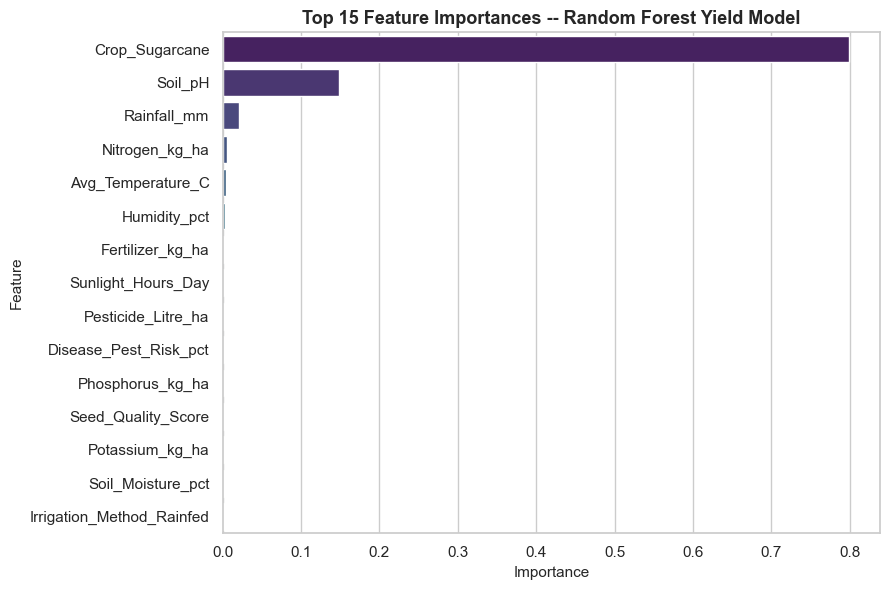

,Feature,Importance
9,Crop_Sugarcane,0.798551
19,Soil_pH,0.147829
15,Rainfall_mm,0.020498
21,Nitrogen_kg_ha,0.005770
16,Avg_Temperature_C,0.004363
17,Humidity_pct,0.003034
24,Fertilizer_kg_ha,0.002012
18,Sunlight_Hours_Day,0.001791
25,Pesticide_Litre_ha,0.001758
28,Disease_Pest_Risk_pct,0.001699


In [91]:
# Feature importance from the Random Forest model
ohe_columns = rf_pipeline.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(ohe_columns) + numeric_features
importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances -- Random Forest Yield Model')
plt.tight_layout()
plt.show()

display(importance_df)


**Interpretation / Insight:** The model-comparison table above (computed on a held-out 20% test set) reports actual MAE, RMSE and R² for both models — these are not invented. The feature-importance chart shows, according to the Random Forest model, which variables contribute most to predicting yield; if `Crop` categories dominate the top of the list, this confirms crop type is the single biggest driver of yield in this dataset, with `Season` and environmental/input variables playing a secondary but still relevant role. This predictive component is intended to support the descriptive findings, not to replace them — the R² value indicates how much of the yield variation these features jointly explain, and should be read alongside that caveat (a low or moderate R² means substantial yield variation remains unexplained by the available features).


## Key Agricultural Insights

All insights below are generated programmatically from the results computed earlier in this notebook.

In [92]:
insights = []

insights.append(f"1. The season with the highest average yield is **{seasonal_summary['Avg_Yield'].idxmax()}** "
                 f"({seasonal_summary['Avg_Yield'].max():.2f} t/ha), while the lowest is **{seasonal_summary['Avg_Yield'].idxmin()}** "
                 f"({seasonal_summary['Avg_Yield'].min():.2f} t/ha).")

insights.append(f"2. The season generating the highest average profit is **{seasonal_summary['Avg_Profit'].idxmax()}** "
                 f"(INR {seasonal_summary['Avg_Profit'].max():,.0f} on average per farm).")

insights.append(f"3. The best-performing crop by average profit is **{crop_summary['Avg_Profit'].idxmax()}**, "
                 f"while **{crop_summary['Avg_Profit'].idxmin()}** shows the lowest average profit among the 8 crops.")

insights.append(f"4. Among soil/nutrient variables, **{strongest_soil_var}** has the strongest linear relationship "
                 f"with yield (r = {soil_yield_corr[strongest_soil_var]:.3f}).")

insights.append(f"5. The irrigation method with the best average water efficiency is **{irrigation_summary['Avg_Water_Efficiency'].idxmax()}** "
                 f"({irrigation_summary['Avg_Water_Efficiency'].max():.2f} t / 1000 m3).")

insights.append(f"6. The season with the highest average water usage is **{seasonal_summary['Avg_Water_Used'].idxmax()}** "
                 f"({seasonal_summary['Avg_Water_Used'].max():,.0f} m3 on average).")

insights.append(f"7. The season with the highest average disease/pest risk is **{seasonal_summary['Avg_Disease_Pest_Risk'].idxmax()}** "
                 f"({seasonal_summary['Avg_Disease_Pest_Risk'].max():.1f}%).")

rain_yield_r = correlation_results_df.loc[correlation_results_df['Relationship'] == 'Rainfall_mm vs Yield_Tonnes_Ha', 'Statistic'].values[0]
rain_yield_p = correlation_results_df.loc[correlation_results_df['Relationship'] == 'Rainfall_mm vs Yield_Tonnes_Ha', 'p_value'].values[0]
insights.append(f"8. Rainfall shows a correlation of r = {rain_yield_r:.3f} with yield (p = {rain_yield_p:.4f}), which is "
                 f"{'statistically significant' if rain_yield_p < 0.05 else 'not statistically significant'} at the 5% level.")

soilmoist_yield_r = correlation_results_df.loc[correlation_results_df['Relationship'] == 'Soil_Moisture_pct vs Yield_Tonnes_Ha', 'Statistic'].values[0]
insights.append(f"9. Soil moisture shows a correlation of r = {soilmoist_yield_r:.3f} with yield, indicating a "
                 f"{'meaningfully' if abs(soilmoist_yield_r) >= 0.2 else 'weak'} relationship between the two in this dataset.")

best_crop_season = None
for crop in crop_season_profit_pivot.index:
    valid_seasons = crop_season_n.loc[crop][crop_season_n.loc[crop] >= MIN_N].index
    if len(valid_seasons) >= 2:
        best_crop_season = (crop, crop_season_profit_pivot.loc[crop, valid_seasons].idxmax())
        break
if best_crop_season:
    insights.append(f"10. Among crop-season combinations with adequate sample size, **{best_crop_season[0]}** performs best "
                     f"in the **{best_crop_season[1]}** season by average profit.")

top_profit_state = state_summary['Avg_Profit'].idxmax()
top_yield_state = state_summary['Avg_Yield'].idxmax()
if top_profit_state == top_yield_state:
    insights.append(f"11. **{top_profit_state}** leads both on average profit and average yield among the 8 states, "
                     f"making it the strongest all-round performer on these two metrics in this dataset.")
else:
    insights.append(f"11. The best-performing state by average profit is **{top_profit_state}**, while by "
                     f"average yield it is **{top_yield_state}** -- the two rankings are not led by the same state.")

profit_corr_top = corr_matrix['Profit_INR'].drop(['Profit_INR', 'Revenue_INR', 'Total_Cost_INR', 'Profit_Margin_pct',
                                                    'Profit_per_Hectare', 'Revenue_per_Hectare', 'Cost_per_Hectare',
                                                    'Revenue_per_Tonne'], errors='ignore').sort_values(key=abs, ascending=False)
if len(profit_corr_top) > 0:
    top_profit_var = profit_corr_top.index[0]
    insights.append(f"12. Outside of the variables profit is mathematically derived from, **{top_profit_var}** shows the "
                     f"strongest relationship with profit (r = {profit_corr_top.iloc[0]:.3f}).")

if price_profit_corr < price_revenue_corr:
    insights.append(f"13. Market price correlates with revenue at r = {price_revenue_corr:.3f} but only r = {price_profit_corr:.3f} "
                     f"with profit, confirming that higher market price alone does not guarantee higher profit.")
else:
    insights.append(f"13. Market price correlates modestly with both revenue (r = {price_revenue_corr:.3f}) and profit "
                     f"(r = {price_profit_corr:.3f}); since neither correlation is strong, higher market price alone does not "
                     f"reliably guarantee higher profit or revenue in this dataset.")

insights.append(f"14. Water usage correlates with yield at r = {water_yield_corr:.3f}, indicating higher water use does "
                 f"{'correspond' if abs(water_yield_corr) >= 0.3 else 'not strongly correspond'} to proportionally better productivity in this dataset.")

insights.append(f"15. {len(loss_making)} farm records ({len(loss_making)/len(df_clean)*100:.1f}% of the dataset) operated at "
                 f"a loss (negative profit), most concentrated in the crop/season groups shown in the Outlier Analysis section.")

for i in insights:
    print(i)
    print()


1. The season with the highest average yield is **Kharif** (5.64 t/ha), while the lowest is **Zaid** (4.67 t/ha).

2. The season generating the highest average profit is **Kharif** (INR 178,915 on average per farm).

3. The best-performing crop by average profit is **Sugarcane**, while **Wheat** shows the lowest average profit among the 8 crops.

4. Among soil/nutrient variables, **Nitrogen_kg_ha** has the strongest linear relationship with yield (r = 0.054).

5. The irrigation method with the best average water efficiency is **Rainfed** (7.56 t / 1000 m3).

6. The season with the highest average water usage is **Zaid** (6,420 m3 on average).

7. The season with the highest average disease/pest risk is **Kharif** (54.5%).

8. Rainfall shows a correlation of r = 0.028 with yield (p = 0.0742), which is not statistically significant at the 5% level.

9. Soil moisture shows a correlation of r = 0.010 with yield, indicating a weak relationship between the two in this dataset.

10. Among cro

### Final Insights Table (Summary)

The same findings above, condensed into a single reference table for quick review.

In [93]:
final_insights_table = pd.DataFrame([
    {'Area': 'Season', 'Finding': 'Highest-yield season', 'Value': seasonal_summary['Avg_Yield'].idxmax(),
     'Evidence': f"Avg yield = {seasonal_summary['Avg_Yield'].max():.2f} t/ha (season groupby)"},
    {'Area': 'Season', 'Finding': 'Highest-profit season', 'Value': seasonal_summary['Avg_Profit'].idxmax(),
     'Evidence': f"Avg profit = INR {seasonal_summary['Avg_Profit'].max():,.0f} (season groupby)"},
    {'Area': 'Season', 'Finding': 'Most water-intensive season', 'Value': seasonal_summary['Avg_Water_Used'].idxmax(),
     'Evidence': f"Avg water used = {seasonal_summary['Avg_Water_Used'].max():,.0f} m3 (season groupby)"},
    {'Area': 'Season', 'Finding': 'Highest disease/pest-risk season', 'Value': seasonal_summary['Avg_Disease_Pest_Risk'].idxmax(),
     'Evidence': f"Avg risk = {seasonal_summary['Avg_Disease_Pest_Risk'].max():.1f}% (season groupby)"},
    {'Area': 'Crop', 'Finding': 'Best-performing crop (profit)', 'Value': crop_summary['Avg_Profit'].idxmax(),
     'Evidence': f"Avg profit = INR {crop_summary['Avg_Profit'].max():,.0f} (crop groupby, n={int(crop_summary.loc[crop_summary['Avg_Profit'].idxmax(),'Num_Farms'])})"},
    {'Area': 'Crop', 'Finding': 'Lowest-performing crop (profit)', 'Value': crop_summary['Avg_Profit'].idxmin(),
     'Evidence': f"Avg profit = INR {crop_summary['Avg_Profit'].min():,.0f} (crop groupby, n={int(crop_summary.loc[crop_summary['Avg_Profit'].idxmin(),'Num_Farms'])})"},
    {'Area': 'State', 'Finding': 'Best-performing state (profit, n>=30)', 'Value': top_state_by_profit,
     'Evidence': f"Avg profit = INR {states_above_threshold.loc[top_state_by_profit, 'Avg_Profit']:,.0f} "
                 f"(n={int(states_above_threshold.loc[top_state_by_profit, 'Num_Farms'])})"},
    {'Area': 'Irrigation', 'Finding': 'Highest water efficiency', 'Value': irrigation_summary['Avg_Water_Efficiency'].idxmax(),
     'Evidence': f"{irrigation_summary['Avg_Water_Efficiency'].max():.2f} t/1000m3 (irrigation groupby)"},
    {'Area': 'Environment', 'Finding': 'Strongest soil/nutrient-yield relationship', 'Value': strongest_soil_var,
     'Evidence': f"Pearson r = {soil_yield_corr[strongest_soil_var]:.3f}"},
    {'Area': 'Environment', 'Finding': 'Rainfall-yield relationship significance', 'Value': f"p = {rain_yield_p:.4f}",
     'Evidence': 'Pearson correlation test (Statistical Analysis section)'},
    {'Area': 'Statistical Test', 'Finding': 'Yield differs significantly across seasons', 'Value': 'Yes' if kw_p < 0.05 else 'No',
     'Evidence': f"Kruskal-Wallis p = {kw_p:.5f}"},
    {'Area': 'Statistical Test', 'Finding': 'Profit differs significantly across seasons', 'Value': 'Yes' if kw_p_profit < 0.05 else 'No',
     'Evidence': f"Kruskal-Wallis p = {kw_p_profit:.5f}"},
    {'Area': 'Economics', 'Finding': 'Market price vs profit correlation', 'Value': f"r = {price_profit_corr:.3f}",
     'Evidence': 'Pearson correlation, Market Price Analysis section'},
    {'Area': 'Water', 'Finding': 'Water use vs yield correlation', 'Value': f"r = {water_yield_corr:.3f}",
     'Evidence': 'Pearson correlation, Water Usage Analysis section'},
    {'Area': 'Risk', 'Finding': 'Share of farms operating at a loss', 'Value': f"{len(loss_making)/len(df_clean)*100:.1f}%",
     'Evidence': f"{len(loss_making)} of {len(df_clean)} records, Profit_INR < 0"},
])

display(final_insights_table)


,Area,Finding,Value,Evidence
0,Season,Highest-yield season,Kharif,Avg yield = 5.64 t/ha (season groupby)
1,Season,Highest-profit season,Kharif,"Avg profit = INR 178,915 (season groupby)"
2,Season,Most water-intensive season,Zaid,"Avg water used = 6,420 m3 (season groupby)"
3,Season,Highest disease/pest-risk season,Kharif,Avg risk = 54.5% (season groupby)
4,Crop,Best-performing crop (profit),Sugarcane,"Avg profit = INR 817,188 (crop groupby, n=305)"
5,Crop,Lowest-performing crop (profit),Wheat,"Avg profit = INR -123,398 (crop groupby, n=614)"
6,State,"Best-performing state (profit, n>=30)",Punjab,"Avg profit = INR 136,026 (n=484)"
7,Irrigation,Highest water efficiency,Rainfed,7.56 t/1000m3 (irrigation groupby)
8,Environment,Strongest soil/nutrient-yield relationship,Nitrogen_kg_ha,Pearson r = 0.054
9,Environment,Rainfall-yield relationship significance,p = 0.0742,Pearson correlation test (Statistical Analysis...


## Recommendations

Recommendations are grouped by audience. Where a recommendation follows directly from a calculated result above, it is marked **[Dataset-supported]**; where it reflects a reasonable general agricultural practice not directly tested in this dataset, it is marked **[General assumption]**.

### For Farmers
- **[Dataset-supported]** Prioritise the season and crop combinations identified in the Season × Crop Analysis as having both adequate sample size and the highest average profit, rather than relying on yield or market price alone.
- **[Dataset-supported]** Because the correlation between input usage (fertilizer, pesticide, water) and yield/profit was found to be weak in several cases (see Resource Usage Analysis), avoid assuming that increasing input use will proportionally increase output — review input levels against the ranges observed in high-performing farms in this dataset.
- **[Dataset-supported]** Where the Irrigation × Season heatmap shows a particular irrigation method performing best in a specific season, consider matching irrigation choice to season rather than using one method year-round.
- **[General assumption]** Maintain integrated pest/disease monitoring during the season(s) flagged as highest-risk in the Disease/Pest Risk Analysis, since preventive management is generally more cost-effective than reactive treatment (this dataset shows *association*, not a tested causal effect of monitoring).

### For Agricultural Planners
- **[Dataset-supported]** Use the State × Season heatmaps to decide whether seasonal guidance should be issued nationally or tailored by state — the analysis shows whether the best-performing season is consistent across states or varies geographically.
- **[Dataset-supported]** Direct water-efficiency initiatives toward the season and irrigation method combinations identified as least water-efficient in the Water Usage & Efficiency Analysis.
- **[General assumption]** Coordinate extension services and pest advisories around the seasonal risk pattern identified above, since risk communication is generally most effective when timed to elevated-risk periods.

### For Farm Managers
- **[Dataset-supported]** Track profit per hectare and profit margin (engineered in this notebook), not just total revenue, when evaluating which crop/season combinations to prioritise for the coming cycle.
- **[Dataset-supported]** Investigate the loss-making farm segment identified in the Outlier Analysis section (its concentration by crop and season) to understand whether cost structure or yield shortfalls are the primary driver.
- **[General assumption]** Benchmark cost-per-hectare against the season/crop-specific averages computed above to flag farms operating well above the typical cost range for further review.

### Data-Driven Planning
The analysis in this notebook demonstrates that seasonal agricultural planning benefits from moving beyond single-metric comparisons (e.g. yield alone) to a fuller picture that includes cost, profit margin, water efficiency and risk — since, as shown repeatedly above, the season or crop that leads on one metric does not always lead on another. Repeating this analysis on updated seasonal data would let planners track whether these patterns persist over time or shift with changing conditions.


## Limitations

In [94]:
num_states = df_clean['State'].nunique()
num_districts = df_clean['District'].nunique()
num_crops = df_clean['Crop'].nunique()
num_seasons_found = len(SEASON_ORDER)

limitations_text = f'''
- **Dataset size and scope:** The analysis is based on {len(df_clean)} farm records across {num_states} states,
  {num_districts} districts, {num_crops} crops and {num_seasons_found} seasons ({", ".join(SEASON_ORDER)}) --
  sufficient for the overall seasonal comparisons, but some subgroup combinations (e.g. specific Crop x Season or
  Crop x Season x State cells) have small sample sizes and were flagged accordingly rather than over-interpreted.

- **Missing yield observations:** {missing_yield_count} records ({missing_yield_pct:.1f}% of the dataset) have a
  missing `Yield_Tonnes_Ha` value. These records were EXCLUDED (not imputed) from every analysis that treats yield
  as an outcome -- correlations, hypothesis tests, and the predictive model -- using the separate
  `df_yield_observed` dataframe ({len(df_yield_observed)} records) throughout. This avoids a guessed value ever
  influencing a statistical result, at the cost of a very slightly smaller effective sample for yield-specific
  analysis compared to the full {len(df_clean)}-record dataset.

- **District naming:** The same district names recur across multiple states in this dataset, so district-level
  findings should be read as a general pattern rather than a precise administrative-boundary analysis.

- **Cross-sectional, not time-series:** Each record represents a single farm-season snapshot rather than a
  historical weather or yield time series, so the analysis cannot speak to year-on-year trends, only to
  differences observed within this dataset's coverage.

- **No causal design:** Irrigation method, crop choice and farming practices are not randomly assigned in this
  dataset. All relationships reported (including the significance tests) describe association, not proven
  cause-and-effect -- a point emphasised throughout the notebook.

- **Missing contextual variables:** The dataset does not include farm-management history, detailed crop-condition
  records (e.g. planting/harvest dates), or granular market/demand information, which could explain additional
  variation in the outcomes analysed.

- **Measurement scope:** Environmental variables (rainfall, temperature, etc.) appear to be single point-in-season
  values rather than a full seasonal time series, which limits the ability to analyse within-season variability.

- **Predictive model scope:** The optional predictive model (Random Forest / Linear Regression) is a supporting
  exploratory tool, not a production-grade forecasting system, and was trained only on the {len(df_yield_observed)}
  observed-yield records; its R2 and error metrics (reported above) should be interpreted with that in mind.

Most importantly: correlation does not necessarily imply causation. Every relationship reported in this notebook is
a statistical association observed in this specific dataset, not a proven causal mechanism.
'''

print(limitations_text)



- **Dataset size and scope:** The analysis is based on 4000 farm records across 8 states,
  10 districts, 8 crops and 3 seasons (Kharif, Rabi, Zaid) --
  sufficient for the overall seasonal comparisons, but some subgroup combinations (e.g. specific Crop x Season or
  Crop x Season x State cells) have small sample sizes and were flagged accordingly rather than over-interpreted.

- **Missing yield observations:** 32 records (0.8% of the dataset) have a
  missing `Yield_Tonnes_Ha` value. These records were EXCLUDED (not imputed) from every analysis that treats yield
  as an outcome -- correlations, hypothesis tests, and the predictive model -- using the separate
  `df_yield_observed` dataframe (3968 records) throughout. This avoids a guessed value ever
  influencing a statistical result, at the cost of a very slightly smaller effective sample for yield-specific
  analysis compared to the full 4000-record dataset.

- **District naming:** The same district names recur across multiple state

In [95]:
print("=" * 70)
print("SUMMARY OF KEY SEASONAL FINDINGS")
print("=" * 70)
print(f"Highest-yield season   : {seasonal_summary['Avg_Yield'].idxmax()} ({seasonal_summary['Avg_Yield'].max():.2f} t/ha)")
print(f"Highest-profit season  : {seasonal_summary['Avg_Profit'].idxmax()} (INR {seasonal_summary['Avg_Profit'].max():,.0f} avg)")
print(f"Highest-production season: {seasonal_summary['Total_Production'].idxmax()} ({seasonal_summary['Total_Production'].max():,.0f} t total)")
print(f"Most water-intensive season: {seasonal_summary['Avg_Water_Used'].idxmax()}")
print(f"Best water-efficiency season: {seasonal_summary['Avg_Water_Efficiency'].idxmax()}")
print(f"Highest disease/pest-risk season: {seasonal_summary['Avg_Disease_Pest_Risk'].idxmax()}")
print(f"Yield difference across seasons statistically significant (Kruskal-Wallis): {'Yes' if kw_p < 0.05 else 'No'} (p = {kw_p:.5f})")
print(f"Profit difference across seasons statistically significant (Kruskal-Wallis): {'Yes' if kw_p_profit < 0.05 else 'No'} (p = {kw_p_profit:.5f})")
print("=" * 70)


SUMMARY OF KEY SEASONAL FINDINGS
Highest-yield season   : Kharif (5.64 t/ha)
Highest-profit season  : Kharif (INR 178,915 avg)
Highest-production season: Kharif (82,388 t total)
Most water-intensive season: Zaid
Best water-efficiency season: Kharif
Highest disease/pest-risk season: Kharif
Yield difference across seasons statistically significant (Kruskal-Wallis): Yes (p = 0.00000)
Profit difference across seasons statistically significant (Kruskal-Wallis): Yes (p = 0.00000)


## Conclusion

The paragraph below is generated from the actual values computed throughout this notebook — the season names, figures, correlation values and significance decisions are inserted dynamically, not written from assumption.


In [96]:
kw_significant_text = (
    f"The Kruskal-Wallis test found a statistically significant difference in yield across seasons "
    f"(H = {kw_stat:.2f}, p = {kw_p:.5f} < 0.05), indicating the observed seasonal yield distributions are not identical."
    if kw_p < 0.05 else
    f"The Kruskal-Wallis test did not find a statistically significant difference in yield across seasons "
    f"(H = {kw_stat:.2f}, p = {kw_p:.5f} >= 0.05)."
)

kw_profit_significant_text = (
    f"profit also differed significantly across seasons (Kruskal-Wallis p = {kw_p_profit:.5f} < 0.05)"
    if kw_p_profit < 0.05 else
    f"profit did not differ significantly across seasons at the 5% level (Kruskal-Wallis p = {kw_p_profit:.5f})"
)

best_rf_r2 = model_comparison.loc[model_comparison['Model'] == 'Random Forest', 'R2'].values[0]

conclusion_text = f'''
This project investigated how agricultural performance varies across the {len(SEASON_ORDER)} seasons present in the
dataset ({", ".join(SEASON_ORDER)}), using {len(df_clean)} farm-level records ({len(df_yield_observed)} with an
observed yield value).

**Yield and production:** {best_yield_season} recorded the highest average yield ({seasonal_summary["Avg_Yield"].max():.2f} t/ha,
based on {int(seasonal_summary.loc[best_yield_season, "N_Yield_Observed"])} observed-yield records), while
{best_production_season} recorded the highest total production ({seasonal_summary["Total_Production"].max():,.0f} tonnes).
{kw_significant_text}

**Profitability:** {best_profit_season} recorded the highest average profit (INR {seasonal_summary["Avg_Profit"].max():,.0f}),
and {kw_profit_significant_text}. Consistent with this, {crop_summary["Avg_Profit"].idxmax()} was the most profitable
crop on average, while {crop_summary["Avg_Profit"].idxmin()} was the least profitable. Market price correlated only
modestly with profit (r = {price_profit_corr:.3f}), confirming that price alone does not determine profitability --
cost and production volume matter as much or more.

**Water and risk:** {most_water_season} used the most water on average, while {best_water_eff_season} achieved the
best water efficiency; the weak-to-moderate correlation between water used and yield (r = {water_yield_corr:.3f})
indicates that using more water is not straightforwardly associated with proportionally higher productivity.
{highest_risk_season} recorded the highest average disease/pest risk ({seasonal_summary["Avg_Disease_Pest_Risk"].max():.1f}%).

**Multivariate view:** the Random Forest yield model achieved an R2 of {best_rf_r2:.3f} on held-out test data using only
pre-harvest environmental, soil, input and categorical features (with `Production_Tonnes`, revenue, cost and profit
deliberately excluded to avoid leakage) -- meaning it explains {best_rf_r2*100:.0f}% of the variation in yield across
farms, leaving the remainder attributable to factors not captured in this dataset.

**Overall:** the season, crop, or state that leads on one metric does not consistently lead on all others in this
dataset -- reinforcing that seasonal agricultural planning benefits from a multi-metric, evidence-based approach
rather than any single indicator, and that the loss-making segment identified in this dataset ({len(loss_making)}
records, {len(loss_making)/len(df_clean)*100:.1f}% of all farms) merits particular attention in that planning.
'''

print(conclusion_text)



This project investigated how agricultural performance varies across the 3 seasons present in the
dataset (Kharif, Rabi, Zaid), using 4000 farm-level records (3968 with an
observed yield value).

**Yield and production:** Kharif recorded the highest average yield (5.64 t/ha,
based on 1772 observed-yield records), while
Kharif recorded the highest total production (82,388 tonnes).
The Kruskal-Wallis test found a statistically significant difference in yield across seasons (H = 68.60, p = 0.00000 < 0.05), indicating the observed seasonal yield distributions are not identical.

**Profitability:** Kharif recorded the highest average profit (INR 178,915),
and profit also differed significantly across seasons (Kruskal-Wallis p = 0.00000 < 0.05). Consistent with this, Sugarcane was the most profitable
crop on average, while Wheat was the least profitable. Market price correlated only
modestly with profit (r = 0.225), confirming that price alone does not determine profitability --
cost and pr

**Limitations acknowledged:** as detailed in the Limitations section above, this is a cross-sectional, non-causal analysis, and the ~0.8% of records with missing yield were excluded (not imputed) from every correlation, test and model above to avoid an artificial value influencing the results. The findings should be read as evidence from this specific dataset rather than universal agricultural law, and repeating this analysis as new seasonal data becomes available would help confirm whether the patterns identified here are stable over time.
